In [18]:
# ==============================================================================
# CELL 1: IMPORTS
# ==============================================================================

import os
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T
import torchvision.models as models
import torchvision.transforms.functional as TF
import torch.nn.functional as F
import random

In [19]:
# ==============================================================================
# ESTILO UNIFICADO PARA FIGURAS DEL TRABAJO DE GRADO
# ==============================================================================

import matplotlib.pyplot as plt
import matplotlib as mpl

def setup_thesis_style():
    """
    Configura estilo profesional consistente para todas las figuras.
    """
    # Estilo base
    plt.style.use('seaborn-v0_8-whitegrid')
    
    # Parámetros personalizados
    thesis_params = {
        # Fuentes
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'DejaVu Serif'],
        'font.size': 10,
        'axes.titlesize': 11,
        'axes.labelsize': 10,
        'xtick.labelsize': 9,
        'ytick.labelsize': 9,
        'legend.fontsize': 9,
        'legend.title_fontsize': 10,
        
        # Líneas y markers
        'lines.linewidth': 1.5,
        'lines.markersize': 5,
        
        # Ejes
        'axes.linewidth': 0.8,
        'axes.grid': True,
        'grid.alpha': 0.3,
        'grid.linewidth': 0.5,
        
        # Figura
        'figure.dpi': 150,
        'savefig.dpi': 300,
        'savefig.bbox': 'tight',
        'savefig.pad_inches': 0.1,
        
        # LaTeX
        'text.usetex': False,  # True si tienes LaTeX instalado
        'mathtext.fontset': 'stix',
    }
    
    mpl.rcParams.update(thesis_params)
    
    return thesis_params

# Paleta de colores profesional (colorblind-friendly, print-safe)
COLORS = {
    # Primarios
    'train': '#0077BB',       # Azul fuerte - entrenamiento
    'val': '#CC3311',         # Rojo - validación
    
    # Parámetros
    'D': '#0077BB',           # Azul - DMI
    'sigma': '#EE7733',       # Naranja - sigma
    
    # Componentes de loss
    'regression': '#0077BB',  # Azul
    'spectral': '#009988',    # Verde azulado
    'energy': '#EE7733',      # Naranja
    
    # Referencias
    'reference': '#555555',   # Gris oscuro
    'highlight': '#CC3311',   # Rojo para destacar
    'neutral': '#BBBBBB',     # Gris claro
}

# Llamar al inicio de tu notebook
setup_thesis_style()

{'font.family': 'serif',
 'font.serif': ['Times New Roman', 'DejaVu Serif'],
 'font.size': 10,
 'axes.titlesize': 11,
 'axes.labelsize': 10,
 'xtick.labelsize': 9,
 'ytick.labelsize': 9,
 'legend.fontsize': 9,
 'legend.title_fontsize': 10,
 'lines.linewidth': 1.5,
 'lines.markersize': 5,
 'axes.linewidth': 0.8,
 'axes.grid': True,
 'grid.alpha': 0.3,
 'grid.linewidth': 0.5,
 'figure.dpi': 150,
 'savefig.dpi': 300,
 'savefig.bbox': 'tight',
 'savefig.pad_inches': 0.1,
 'text.usetex': False,
 'mathtext.fontset': 'stix'}

In [20]:
# ==============================================================================
# CELL 2: CONFIGURATION (CORRECTED)
# ==============================================================================

# -----------------------------
# 1) Data Paths
# -----------------------------
CSV_PATH = Path("../mumax_dataset_ku_by_block_disorder_phy_corrected_3/training_index.csv")
IMG_DIR = Path("../images/corrected_3")
NPY_DIR = Path("../mumax_dataset_ku_by_block_disorder_phy_corrected_3")

IMG_INDEX_COL = "run_id"  

COL_D = "Dind"
COL_SIGMA = "sigma_eff"

IMG_EXT = ".png"
IMG_PREFIX = "mz_binary_"
NPY_PREFIX = "run_"

# -----------------------------
# 2) Physical Constants
# -----------------------------
PHYS_PARAMS = {
    'Aex': 3.1e-11,        # Exchange stiffness [J/m]
    'Ms': 1.445e6,         # Saturation magnetization [A/m]
    'Ku': 1.6e6,           # Base anisotropy [J/m³]
    'cell_x': 4e-9,        # Cell size x [m]
    'cell_y': 4e-9,        # Cell size y [m]
    'thickness': 0.9e-9,   # Film thickness [m]
}

PHYS_DERIVED = {
    'Q': np.sqrt(PHYS_PARAMS['Aex'] * PHYS_PARAMS['Ku']),
    'D_critical': 4 * np.sqrt(PHYS_PARAMS['Aex'] * PHYS_PARAMS['Ku']) / np.pi,
    'exchange_length': np.sqrt(PHYS_PARAMS['Aex'] / PHYS_PARAMS['Ku']),
    'domain_wall_width': np.pi * np.sqrt(PHYS_PARAMS['Aex'] / PHYS_PARAMS['Ku']),
}

ID_D_RANGE = (0.3e-3, 1.5e-3)      # In-distribution D range [J/m²]
ID_SIGMA_RANGE = (0.02, 0.15)      # In-distribution σ range

# -----------------------------
# 3) Training Config
# -----------------------------
BATCH_SIZE = 15
LR = 1e-4
EPOCHS = 100
VAL_RATIO = 0.15
RANDOM_SEED = 42

MODEL_TYPE = "physics_guided_cnn"
USE_AUGMENTATION = False

# Loss weights
LOSS_WEIGHTS = {
    'regression': 1.0,          # Supervisado para D y σ
    'spectral_sigma': 0.8,      
    'mz_var_sigma': 0.0,        # mz_var_mean → σ (r = 0.79)
}

# Calibración REAL de mz_var_mean (de sanity_test_results.csv)
PHYSICS_CALIBRATION = {
    'mz_var_slope': 0.791200,
    'mz_var_intercept': 0.053256,
}
# Relación: mz_var_mean ≈ 0.053 + 0.791 * σ
# Inversión: σ ≈ (mz_var_mean - 0.053) / 0.791
# R² = 0.626

# Annealing configuration
USE_ANNEALING = True
WARMUP_EPOCHS = 20

# Gradient tracking
TRACK_GRADIENTS = True
GRAD_TRACK_INTERVAL = 20

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# -----------------------------
# 4) Output Directories
# -----------------------------
RUN_TAG = "physics_guided_spectral0.8_nonfiltered"
OUT_DIR = Path(f"./outputs_ablation_final/{RUN_TAG}")
OUT_DIR.mkdir(parents=True, exist_ok=True)

CKPT_DIR = OUT_DIR / "checkpoints"
FIG_DIR  = OUT_DIR / "figures"
MET_DIR  = OUT_DIR / "metrics"

for d in [CKPT_DIR, FIG_DIR, MET_DIR]:
    d.mkdir(parents=True, exist_ok=True)
    
PINN_CKPT_PATH = CKPT_DIR / f"pinn_{RUN_TAG}.pt"
SCALER_PATH    = CKPT_DIR / f"scalers_{RUN_TAG}.pkl"

LOSS_PLOT_PATH     = FIG_DIR / f"loss_curves_{RUN_TAG}.png"
HEATMAP_D_PATH     = FIG_DIR / f"heatmap_err_D_{RUN_TAG}.png"
HEATMAP_SIGMA_PATH = FIG_DIR / f"heatmap_err_sigma_{RUN_TAG}.png"

PRED_IMG_DIR = OUT_DIR / "pred_images"
PRED_IMG_DIR.mkdir(parents=True, exist_ok=True)

# Print configuration summary
print(f"\n{'='*60}")
print(f"PHYSICS-GUIDED CNN CONFIGURATION")
print(f"{'='*60}")
print(f"\nPhysics Calibration (from data):")
print(f"  mz_var_mean = {PHYSICS_CALIBRATION['mz_var_intercept']:.4f} + {PHYSICS_CALIBRATION['mz_var_slope']:.4f} * σ")
print(f"  R² = 0.626")
print(f"\nLoss Weights:")
for key, val in LOSS_WEIGHTS.items():
    status = "✓ active" if val > 0 else "✗ disabled"
    print(f"  {key}: {val} {status}")
print(f"\nAnnealing: {'Enabled' if USE_ANNEALING else 'Disabled'}")
if USE_ANNEALING:
    print(f"  Warmup epochs: {WARMUP_EPOCHS}")
print(f"\nOutput: {OUT_DIR}")
print(f"{'='*60}\n")

TRAIN = True

Device: cuda

PHYSICS-GUIDED CNN CONFIGURATION

Physics Calibration (from data):
  mz_var_mean = 0.0533 + 0.7912 * σ
  R² = 0.626

Loss Weights:
  regression: 1.0 ✓ active
  spectral_sigma: 0.8 ✓ active
  mz_var_sigma: 0.0 ✗ disabled

Annealing: Enabled
  Warmup epochs: 20

Output: outputs_ablation_final/physics_guided_spectral0.8_nonfiltered



In [21]:
# ¿Con qué datos se hizo el sanity test?
# Ejecuta esto para verificar:
import numpy as np

# Cargar una muestra del sanity test
sample_npy = np.load('../mumax_dataset_ku_by_block_disorder_phy_corrected_3/run_03073/final_3073.npy')  # Ajustar path
mz_from_npy = sample_npy[2]  # Componente z

print(f"mz from npy: min={mz_from_npy.min():.3f}, max={mz_from_npy.max():.3f}")

# vs la imagen
from PIL import Image
img = Image.open('../images/corrected_3/mz_binary_3073.png')
img_array = np.array(img)
print(f"Image: min={img_array.min()}, max={img_array.max()}, dtype={img_array.dtype}")

mz from npy: min=-1.000, max=1.000
Image: min=0, max=65535, dtype=uint16


In [22]:
# ==============================================================================
# CELL 3: PHYSICS FUNCTIONS (RECALIBRADO para rango completo D∈[0,1.5], σ∈[0,0.15])
# ==============================================================================

import torch
import torch.nn.functional as F
import numpy as np

# ============================================================================
# NUEVOS FEATURES ÓPTIMOS (basados en tu análisis)
# ============================================================================
DEFAULT_SPECTRAL_FEATURES = [
    'gradient_mean',      # R² = 0.63 solo, mejor predictor
    'anisotropy',         # Independiente de D (r = -0.04)
    'gradient_max',       
    'high_low_ratio',     
    'edge_roughness',     # R² = 0.62 solo
    'peak_height',        
    'gradient_std',       
    'spectral_entropy',   
    'power_low',          
    'power_mid',          
]

# ============================================================================
# COEFICIENTES CALIBRADOS CON RANGO COMPLETO (CV R² = 0.856)
# ============================================================================
SPECTRAL_COEFFICIENTS = {
    'gradient_mean': 0.063845,
    'anisotropy': -0.002201,
    'gradient_max': -0.010955,
    'high_low_ratio': 0.003000,
    'edge_roughness': -0.024899,
    'peak_height': 0.015203,
    'gradient_std': -0.053370,
    'spectral_entropy': 0.022088,
    'power_low': -0.047417,
    'power_mid': 0.031256,
}

SPECTRAL_INTERCEPT = 0.076971

# ============================================================================
# PARÁMETROS DE NORMALIZACIÓN RECALIBRADOS (mean, std) - RANGO COMPLETO
# ============================================================================
SPECTRAL_NORM_PARAMS = {
    'gradient_mean': (0.007397, 0.002630),
    'anisotropy': (0.297289, 0.191814),
    'gradient_max': (0.388632, 0.079933),
    'high_low_ratio': (0.000156, 0.000087),
    'edge_roughness': (4.375793, 1.126333),
    'peak_height': (0.639363, 0.034481),
    'gradient_std': (0.029768, 0.004686),
    'spectral_entropy': (2.704455, 0.626075),
    'power_low': (0.003940, 0.001482),
    'power_mid': (0.000059, 0.000026),
}
# ==============================================================================
# CELL 3: PHYSICS FUNCTIONS
# ==============================================================================

# =============================================================================
# SPECTRAL FEATURES (spectral_sigma - currently disabled but available)
# =============================================================================

#DEFAULT_SPECTRAL_FEATURES = [
#    'edge_roughness',
#    'gradient_std',        
#    'gradient_mean',       
#    'high_low_ratio',      
#    'gradient_max',        
#    'power_mid',           
#    'power_very_low',      
#    'power_high',          
#    'relative_width',      
#    'anisotropy'
#]
#
#SPECTRAL_COEFFICIENTS = {
#    'edge_roughness': -0.06261865530591953,
#    'gradient_std': -0.1003788761122361,
#    'gradient_mean': 0.07281444928453028,
#    'high_low_ratio': 0.007331868139312743,
#    'gradient_max': -0.005507362718208809,
#    'power_mid': 0.05960002575113261,
#    'power_very_low': 0.03757093221234066,
#    'power_high': -0.019617505101020297,
#    'relative_width': 0.004275321118636547,
#    'anisotropy': -0.0014855784465632464
#}
#
#SPECTRAL_INTERCEPT = 0.08418462862512169
#
#SPECTRAL_NORM_PARAMS = {
#    'edge_roughness': (4.1200378704152, 0.8896923627779814),
#    'gradient_std': (0.0310414392494791, 0.003958578369946785),
#    'gradient_mean': (0.008035099018422068, 0.0024565168272737354),
#    'high_low_ratio': (0.00017430976493211248, 8.049796024407529e-05),
#    'gradient_max': (0.4115320633217718, 0.0677471278552067),
#    'power_mid': (6.437438609002766e-05, 2.3605440315921624e-05),
#    'power_very_low': (0.9957278921618324, 0.0013977681061595024),
#    'power_high': (7.687521854226825e-07, 4.783509210331153e-07),
#    'relative_width': (2.169586634978723, 0.41706046435695726),
#    'anisotropy': (0.26947150220312843, 0.1410774043836204)
#}

# ... [MANTENER TODO TU CÓDIGO DE extract_spectral_features, compute_sigma_from_features, etc.] ...

# =============================================================================
# MZ_VAR FUNCTIONS (mz_var_sigma - ACTIVE)
# =============================================================================

def compute_mz_var_mean(mz, block_size=32):
    """
    Varianza media de mz por bloques.
    Correlaciona fuertemente con σ (r = 0.79, R² = 0.626).
    
    ⚠️  IMPORTANTE: Calibrado con mz ∈ [-1, +1] del archivo .npy
        NO usar con imagen normalizada [0, 1].
    
    Args:
        mz: Tensor [B, H, W] con valores en [-1, +1]
        block_size: Tamaño del bloque (default 32 para 512/16)
    
    Returns:
        Tensor [B] con varianza media por muestra
    """
    if mz.dim() == 2:
        mz = mz.unsqueeze(0).unsqueeze(0)
    elif mz.dim() == 3:
        mz = mz.unsqueeze(1)
    
    mz_mean_blocks = F.avg_pool2d(mz, block_size)
    mz_sq_mean_blocks = F.avg_pool2d(mz**2, block_size)
    mz_var_blocks = mz_sq_mean_blocks - mz_mean_blocks**2
    
    return mz_var_blocks.mean(dim=(1, 2, 3))


def compute_sigma_from_mz_var(mz, calibration=None):
    """
    Estima σ desde mz_var_mean usando relación lineal calibrada.
    
    ⚠️  IMPORTANTE: mz debe estar en rango [-1, +1] (del .npy)
    
    Relación: mz_var_mean = 0.0533 + 0.7912 × σ
    Inversión: σ = (mz_var_mean - 0.0533) / 0.7912
    """
    if calibration is None:
        calibration = PHYSICS_CALIBRATION
    
    mz_var = compute_mz_var_mean(mz)
    sigma_physics = (mz_var - calibration['mz_var_intercept']) / calibration['mz_var_slope']
    
    return torch.clamp(sigma_physics, min=0.0, max=0.20)




def compute_spatial_gradients(field, dx, dy):
    """Compute spatial gradients using central differences with periodic BC."""
    grad_x = (torch.roll(field, -1, dims=2) - torch.roll(field, 1, dims=2)) / (2 * dx)
    grad_y = (torch.roll(field, -1, dims=1) - torch.roll(field, 1, dims=1)) / (2 * dy)
    return grad_x, grad_y


def compute_exchange_energy_density(mx, my, mz, Aex, dx, dy):
    """Exchange energy density: e_ex = A·(∇m)²"""
    dmx_dx, dmx_dy = compute_spatial_gradients(mx, dx, dy)
    dmy_dx, dmy_dy = compute_spatial_gradients(my, dx, dy)
    dmz_dx, dmz_dy = compute_spatial_gradients(mz, dx, dy)
    
    grad_m_squared = (
        dmx_dx**2 + dmx_dy**2 +
        dmy_dx**2 + dmy_dy**2 +
        dmz_dx**2 + dmz_dy**2
    )
    
    e_ex = Aex * grad_m_squared
    return e_ex.mean(dim=(1, 2))


def compute_dmi_energy_density(mx, my, mz, D, dx, dy):
    """Interfacial DMI energy density (Néel type)."""
    dmx_dx, _ = compute_spatial_gradients(mx, dx, dy)
    _, dmy_dy = compute_spatial_gradients(my, dx, dy)
    dmz_dx, dmz_dy = compute_spatial_gradients(mz, dx, dy)
    
    dmi_term = (
        mz * dmx_dx - mx * dmz_dx +
        mz * dmy_dy - my * dmz_dy
    )
    
    if isinstance(D, torch.Tensor) and D.dim() > 0:
        D = D.view(-1, 1, 1)
    
    e_dmi = D * dmi_term
    return e_dmi.mean(dim=(1, 2))


# ==============================================================================
# EXTRACCIÓN DE FEATURES ESPECTRALES (ACTUALIZADO)
# ==============================================================================

def extract_spectral_features(imgs, features_to_compute=None):
    """
    Extract spectral features from mz images.
    ACTUALIZADO con peak_height y spectral_entropy.
    """
    if features_to_compute is None:
        features_to_compute = DEFAULT_SPECTRAL_FEATURES
    
    mz = imgs[:, 0, :, :]  # [B, H, W]
    mz_centered = 2.0 * mz - 1.0
    
    B, H, W = mz_centered.shape
    device = imgs.device
    
    features = {}
    
    # =========================================================================
    # GRADIENT-BASED FEATURES
    # =========================================================================
    need_gradients = any(f in features_to_compute for f in [
        'gradient_mean', 'gradient_std', 'gradient_max', 'edge_roughness'
    ])
    
    if need_gradients:
        grad_y = mz_centered[:, 2:, 1:-1] - mz_centered[:, :-2, 1:-1]
        grad_x = mz_centered[:, 1:-1, 2:] - mz_centered[:, 1:-1, :-2]
        
        min_h = min(grad_y.shape[1], grad_x.shape[1])
        min_w = min(grad_y.shape[2], grad_x.shape[2])
        grad_y = grad_y[:, :min_h, :min_w]
        grad_x = grad_x[:, :min_h, :min_w]
        
        grad_mag = torch.sqrt(grad_x**2 + grad_y**2 + 1e-10)
        
        if 'gradient_mean' in features_to_compute:
            features['gradient_mean'] = grad_mag.mean(dim=(1, 2))
        
        if 'gradient_std' in features_to_compute:
            features['gradient_std'] = grad_mag.std(dim=(1, 2))
        
        if 'gradient_max' in features_to_compute:
            features['gradient_max'] = grad_mag.amax(dim=(1, 2))
        
        if 'edge_roughness' in features_to_compute:
            grad_mean = grad_mag.mean(dim=(1, 2))
            grad_std = grad_mag.std(dim=(1, 2))
            features['edge_roughness'] = grad_std / (grad_mean + 1e-10)
    
    # =========================================================================
    # FFT-BASED FEATURES
    # =========================================================================
    need_fft = any(f in features_to_compute for f in [
        'power_low', 'power_mid', 'power_high', 'high_low_ratio',
        'anisotropy', 'peak_height', 'spectral_entropy'
    ])
    
    if need_fft:
        mz_fft_input = mz_centered - mz_centered.mean(dim=(1, 2), keepdim=True)
        
        fft = torch.fft.fft2(mz_fft_input)
        fft_shifted = torch.fft.fftshift(fft, dim=(1, 2))
        power = torch.abs(fft_shifted) ** 2
        
        total_power = power.sum(dim=(1, 2), keepdim=True) + 1e-10
        power_norm = power / total_power
        
        ky = torch.fft.fftfreq(H, device=device).reshape(-1, 1)
        kx = torch.fft.fftfreq(W, device=device).reshape(1, -1)
        ky = torch.fft.fftshift(ky)
        kx = torch.fft.fftshift(kx)
        k_mag = torch.sqrt(kx**2 + ky**2)
        
        # ----- Power in frequency bands -----
        bands = {
            'power_very_low': (0.0, 0.05),
            'power_low': (0.05, 0.15),
            'power_mid': (0.15, 0.30),
            'power_high': (0.30, 0.50)
        }
        
        for band_name, (k_min, k_max) in bands.items():
            if band_name in features_to_compute or 'high_low_ratio' in features_to_compute:
                mask = (k_mag >= k_min) & (k_mag < k_max)
                band_power = (power * mask).sum(dim=(1, 2)) / (total_power.squeeze() + 1e-10)
                features[band_name] = band_power
        
        if 'high_low_ratio' in features_to_compute:
            power_high = features.get('power_high', (power * ((k_mag >= 0.30) & (k_mag < 0.50))).sum(dim=(1, 2)) / total_power.squeeze())
            power_low = features.get('power_low', (power * ((k_mag >= 0.05) & (k_mag < 0.15))).sum(dim=(1, 2)) / total_power.squeeze())
            features['high_low_ratio'] = power_high / (power_low + 1e-10)
        
        # ----- Anisotropy -----
        if 'anisotropy' in features_to_compute:
            Ixx = (power_norm * kx**2).sum(dim=(1, 2))
            Iyy = (power_norm * ky**2).sum(dim=(1, 2))
            Ixy = (power_norm * kx * ky).sum(dim=(1, 2))
            
            trace = Ixx + Iyy
            det = Ixx * Iyy - Ixy**2
            discriminant = torch.clamp((trace/2)**2 - det, min=1e-10)
            
            lambda1 = trace/2 + torch.sqrt(discriminant)
            lambda2 = trace/2 - torch.sqrt(discriminant)
            
            features['anisotropy'] = (lambda1 - lambda2) / (lambda1 + lambda2 + 1e-10)
        
        # ----- Peak Height (NUEVO) -----
        if 'peak_height' in features_to_compute:
            # Altura máxima del espectro normalizado (excluyendo DC)
            center_h, center_w = H // 2, W // 2
            # Crear máscara que excluye el centro (DC)
            dc_mask = torch.ones_like(power_norm[0], dtype=torch.bool)
            dc_radius = 3
            for i in range(-dc_radius, dc_radius + 1):
                for j in range(-dc_radius, dc_radius + 1):
                    if 0 <= center_h + i < H and 0 <= center_w + j < W:
                        dc_mask[center_h + i, center_w + j] = False
            
            # Máximo fuera del DC
            power_no_dc = power_norm * dc_mask.unsqueeze(0)
            features['peak_height'] = power_no_dc.amax(dim=(1, 2))
        
        # ----- Spectral Entropy (NUEVO) -----
        if 'spectral_entropy' in features_to_compute:
            # Entropía de Shannon del espectro de potencia
            # H = -Σ p*log(p)
            power_flat = power_norm.view(B, -1)  # [B, H*W]
            # Evitar log(0)
            power_safe = torch.clamp(power_flat, min=1e-10)
            entropy = -torch.sum(power_safe * torch.log(power_safe), dim=1)
            features['spectral_entropy'] = entropy
            
        if 'relative_width' in features_to_compute:
            w = power_norm / (power_norm.sum(dim=(1,2), keepdim=True) + 1e-10)  # ya es norm, pero seguro
            k = k_mag.unsqueeze(0)  # [1,H,W]
            k_mean = (w * k).sum(dim=(1,2))
            k2_mean = (w * (k**2)).sum(dim=(1,2))
            k_std = torch.sqrt(torch.clamp(k2_mean - k_mean**2, min=1e-12))
            features['relative_width'] = k_std / (k_mean + 1e-10)

    
    return features


def compute_sigma_from_features(imgs, features_to_use=None, return_features=False):
    """
    Compute theoretical σ from image features using calibrated regression.
    RECALIBRADO para rango completo D∈[0,1.5], σ∈[0,0.15]
    CV R² = 0.856
    """
    if features_to_use is None:
        features_to_use = DEFAULT_SPECTRAL_FEATURES
    
    device = imgs.device
    B = imgs.shape[0]
    
    features = extract_spectral_features(imgs, features_to_use)
    
    coeffs = []
    means = []
    stds = []
    feature_values = []
    
    for feat_name in features_to_use:
        if feat_name in features and feat_name in SPECTRAL_COEFFICIENTS:
            coeffs.append(SPECTRAL_COEFFICIENTS[feat_name])
            mean, std = SPECTRAL_NORM_PARAMS[feat_name]
            means.append(mean)
            stds.append(std)
            feature_values.append(features[feat_name])
    
    if len(feature_values) == 0:
        sigma_theory = torch.full((B,), SPECTRAL_INTERCEPT, device=device)
        if return_features:
            return sigma_theory, features
        return sigma_theory
    
    coeffs = torch.tensor(coeffs, device=device, dtype=torch.float32)
    means = torch.tensor(means, device=device, dtype=torch.float32)
    stds = torch.tensor(stds, device=device, dtype=torch.float32)
    
    feature_matrix = torch.stack(feature_values, dim=1)
    
    # =========================================
    # PROTECCIÓN NUMÉRICA
    # =========================================
    # 1. Verificar NaN/Inf en features
    if torch.any(~torch.isfinite(feature_matrix)):
        sigma_theory = torch.full((B,), SPECTRAL_INTERCEPT, device=device)
        if return_features:
            return sigma_theory, features
        return sigma_theory
    
    # 2. Normalizar
    feature_matrix_norm = (feature_matrix - means) / (stds + 1e-10)
    
    # 3. CLAMP para evitar valores extremos (máximo 4 std)
    feature_matrix_norm = torch.clamp(feature_matrix_norm, min=-4.0, max=4.0)
    
    # 4. Calcular σ
    sigma_theory = torch.matmul(feature_matrix_norm, coeffs) + SPECTRAL_INTERCEPT
    
    # 5. Verificar NaN en resultado
    if torch.any(~torch.isfinite(sigma_theory)):
        sigma_theory = torch.where(
            torch.isfinite(sigma_theory),
            sigma_theory,
            torch.full_like(sigma_theory, SPECTRAL_INTERCEPT)
        )
    
    # 6. Clamp a rango físico válido
    sigma_theory = torch.clamp(sigma_theory, min=0.0, max=0.20)
    
    if return_features:
        return sigma_theory, features
    return sigma_theory


print("✓ Physics functions loaded (RECALIBRADO para rango completo)")
print(f"  Features óptimos ({len(DEFAULT_SPECTRAL_FEATURES)}): {DEFAULT_SPECTRAL_FEATURES}")
print(f"  CV R² = 0.856")
print(f"  Rango válido: D ∈ [0, 1.5] mJ/m², σ ∈ [0, 0.15]")

# =============================================================================
# SUMMARY
# =============================================================================
print("✓ Physics functions loaded")
print(f"  ACTIVE:   mz_var_mean → σ (R² = 0.626, weight = {LOSS_WEIGHTS.get('mz_var_sigma', 0)})")
print(f"  INACTIVE: spectral → σ (R² = 0.856, weight = {LOSS_WEIGHTS.get('spectral_sigma', 0)})")
print(f"  ⚠️  mz_var requiere mz ∈ [-1, +1] del archivo .npy")

✓ Physics functions loaded (RECALIBRADO para rango completo)
  Features óptimos (10): ['gradient_mean', 'anisotropy', 'gradient_max', 'high_low_ratio', 'edge_roughness', 'peak_height', 'gradient_std', 'spectral_entropy', 'power_low', 'power_mid']
  CV R² = 0.856
  Rango válido: D ∈ [0, 1.5] mJ/m², σ ∈ [0, 0.15]
✓ Physics functions loaded
  ACTIVE:   mz_var_mean → σ (R² = 0.626, weight = 0.0)
  INACTIVE: spectral → σ (R² = 0.856, weight = 0.8)
  ⚠️  mz_var requiere mz ∈ [-1, +1] del archivo .npy


In [23]:
# ==============================================================================
# CELL 4: LOSS ANNEALING (UPDATED)
# ==============================================================================

class LossAnnealer:
    """
    Gradually increase physics loss weights during training.
    """
    
    def __init__(self, final_weights, warmup_epochs=20, schedule='linear'):
        self.final_weights = final_weights.copy()
        self.warmup_epochs = warmup_epochs
        self.schedule = schedule
        self.weight_history = {k: [] for k in final_weights}
    
    def get_weights(self, epoch, total_epochs):
        """Get weights for current epoch."""
        weights = {}

        # Regression always at full weight
        weights['regression'] = self.final_weights.get('regression', 1.0)

        # Physics weights for σ constraints
        physics_keys = ['spectral_sigma', 'mz_var_sigma']

        if epoch <= self.warmup_epochs:
            physics_factor = 0.0
        else:
            progress = (epoch - self.warmup_epochs) / max(total_epochs - self.warmup_epochs, 1)
            progress = min(progress, 1.0)

            if self.schedule == 'linear':
                physics_factor = progress
            elif self.schedule == 'cosine':
                physics_factor = 0.5 * (1 - np.cos(np.pi * progress))
            elif self.schedule == 'step':
                physics_factor = 1.0 if progress > 0.5 else 0.0
            else:
                physics_factor = progress

        for key in physics_keys:
            weights[key] = self.final_weights.get(key, 0.0) * physics_factor

        # Record history
        for k, v in weights.items():
            if k in self.weight_history:  # ← Pequeña protección
                self.weight_history[k].append(v)
    
        return weights


print("✓ Loss annealing loaded")

✓ Loss annealing loaded


In [24]:
# ==============================================================================
# CELL 6: DATA LOADING (MINIMAL CHANGES - Your code was already good!)
# ==============================================================================

import re
import numpy as np

def extract_ku_list_from_mx3(mx3_path, blocksX=16, blocksY=16):
    text = Path(mx3_path).read_text()
    pattern = r"Ku1\.SetRegion\(\s*regionID\s*,\s*([+-]?\d+(?:\.\d+)?(?:[eE][+-]?\d+)?)\s*\)"
    matches = re.findall(pattern, text)

    n_expected = blocksX * blocksY
    if len(matches) != n_expected:
        raise ValueError(f"Expected {n_expected} Ku entries, found {len(matches)} in {mx3_path}")

    return np.array([float(v) for v in matches], dtype=np.float32)

def ku_list_to_block_matrix(ku_list, blocksX=16, blocksY=16):
    Ku_block = np.zeros((blocksY, blocksX), dtype=np.float32)
    for bx in range(blocksX):
        for by in range(blocksY):
            regionID = bx * blocksY + by
            Ku_block[by, bx] = ku_list[regionID]
    return Ku_block


def load_16bit_image(path):
    """
    Load 16-bit grayscale PNG preserving full dynamic range.
    
    Returns:
        np.ndarray of shape (H, W) with values in [0, 1] as float32
    """
    img = Image.open(path)
    
    if img.mode == 'I;16':
        # Proper 16-bit grayscale
        arr = np.array(img, dtype=np.uint16)
        arr = arr.astype(np.float32) / 65535.0
    elif img.mode == 'I':
        # 32-bit integer (sometimes PIL does this)
        arr = np.array(img, dtype=np.float32)
        arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
    elif img.mode == 'L':
        # Already 8-bit (fallback with warning)
        print(f"WARNING: {path} loaded as 8-bit!")
        arr = np.array(img, dtype=np.float32) / 255.0
    else:
        raise ValueError(f"Unexpected image mode: {img.mode}")
    
    return arr


def load_magnetization_from_npy(npy_path):
    """
    Load full magnetization field from NPY file.
    
    Args:
        npy_path: Path to .npy file with shape (3, nz, ny, nx)
    
    Returns:
        dict with keys 'mx', 'my', 'mz', each shape (nx, ny) as float32
    """
    spins = np.load(npy_path)  # (3, nz, ny, nx)
    
    # Transform to (nx, ny, nz, 3)
    arr = np.moveaxis(spins, 0, -1)      # (nz, ny, nx, 3)
    arr = arr.transpose(2, 1, 0, 3)      # (nx, ny, nz, 3)
    
    # Extract components (assume nz=0 for single layer)
    mx = arr[:, :, 0, 0].astype(np.float32)
    my = arr[:, :, 0, 1].astype(np.float32)
    mz = arr[:, :, 0, 2].astype(np.float32)
    
    return {'mx': mx, 'my': my, 'mz': mz}


class MzDataset(Dataset):
    """
    Dataset for Physics-Informed CNN.
    
    Returns:
    - img: mz visualization [3, H, W] for CNN
    - m_field: full magnetization {mx, my, mz} for energy computation
    - target: (D, sigma) labels
    - run_id: for tracking
    
    NEW: Supports limiting number of samples for data efficiency experiments.
    """

    def __init__(self, csv_path, img_dir, npy_dir, index_col,
                 transform=None,
                 target_mean=None,
                 target_std=None,
                 filter_low_D=True,
                 D_min_threshold=0.3e-3,
                 filter_low_sigma=True,
                 sigma_min_threshold=0.02,
                 load_npy=True,
                 # NEW: Optional sample limit
                 max_samples=None,
                 random_subset_seed=42):
        """
        Args:
            csv_path: Path to CSV with labels
            img_dir: Directory with images
            npy_dir: Directory with NPY files
            index_col: Column name for run_id in CSV
            transform: Optional transforms
            target_mean, target_std: For normalization
            filter_low_D: Whether to filter low D values
            D_min_threshold: Minimum D value
            filter_low_sigma: Whether to filter low sigma values
            sigma_min_threshold: Minimum sigma value
            load_npy: Whether to load NPY files for energy computation
            
            NEW PARAMETERS:
            max_samples: Maximum number of samples to use (None = use all)
            random_subset_seed: Seed for reproducible random subset selection
        """

        self.df = pd.read_csv(csv_path)
        self.df.set_index(index_col, inplace=True)

        self.img_dir = Path(img_dir)
        self.npy_dir = Path(npy_dir)
        self.transform = transform
        self.load_npy = load_npy

        self.records = []
        
        n_filtered_D = 0
        n_filtered_sigma = 0
        n_missing_npy = 0

        # Find all available images
        img_files = sorted(self.img_dir.glob(f"{IMG_PREFIX}*{IMG_EXT}"))

        if len(img_files) == 0:
            raise RuntimeError(f"No images found in {img_dir}")

        for img_path in img_files:
            try:
                run_id = int(img_path.stem.replace(IMG_PREFIX, ""))
            except ValueError:
                continue

            if run_id not in self.df.index:
                continue

            row = self.df.loc[run_id]
            D = float(row[COL_D])
            sigma = float(row[COL_SIGMA])
            
            if filter_low_D and D < D_min_threshold:
                n_filtered_D += 1
                continue
                
            if filter_low_sigma and sigma < sigma_min_threshold:
                n_filtered_sigma += 1
                continue

            # Check if NPY file exists
            npy_path = None
            if self.load_npy:
                run_dir = self.npy_dir / f"run_{run_id:05d}"
                
                if run_dir.exists():
                    npy_files = list(run_dir.glob("*.npy"))
                    if len(npy_files) == 1:
                        npy_path = npy_files[0]
                    elif len(npy_files) > 1:
                        for nf in npy_files:
                            if 'final' in nf.stem.lower() or 'm.npy' == nf.name:
                                npy_path = nf
                                break
                        if npy_path is None:
                            npy_path = npy_files[0]
                
                if npy_path is None or not npy_path.exists():
                    n_missing_npy += 1
                    if self.load_npy:
                        continue

            self.records.append({
                "img_path": img_path,
                "npy_path": npy_path,
                "D": D,
                "sigma": sigma,
                "run_id": run_id
            })

        if len(self.records) == 0:
            raise RuntimeError("No valid (image, label) pairs found.")

        # =====================================================
        # NEW: Limit number of samples if max_samples specified
        # =====================================================
        total_available = len(self.records)
        
        if max_samples is not None and max_samples < total_available:
            # Use random subset for reproducibility
            rng = np.random.RandomState(random_subset_seed)
            indices = rng.choice(total_available, size=max_samples, replace=False)
            indices = sorted(indices)  # Keep sorted for consistency
            self.records = [self.records[i] for i in indices]
            
            print(f"[MzDataset] LIMITED to {max_samples} samples (from {total_available} available)")
        else:
            if max_samples is not None:
                print(f"[MzDataset] max_samples={max_samples} >= available ({total_available}), using all")

        self.target_mean = target_mean
        self.target_std  = target_std

        # Print summary
        print(f"[MzDataset] Loaded {len(self.records)} samples from {img_dir}")
        if filter_low_D:
            print(f"  Filtered {n_filtered_D} samples with D < {D_min_threshold*1e3:.1f} mJ/m²")
        if filter_low_sigma:
            print(f"  Filtered {n_filtered_sigma} samples with σ < {sigma_min_threshold}")
        if self.load_npy and n_missing_npy > 0:
            print(f"  WARNING: {n_missing_npy} samples missing NPY files (skipped)")
        
        # NEW: Print parameter coverage
        if len(self.records) > 0:
            D_vals = [r['D'] for r in self.records]
            s_vals = [r['sigma'] for r in self.records]
            print(f"  D range: [{min(D_vals)*1e3:.2f}, {max(D_vals)*1e3:.2f}] mJ/m²")
            print(f"  σ range: [{min(s_vals):.3f}, {max(s_vals):.3f}]")

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]
    
        # Load image for CNN
        arr = load_16bit_image(r["img_path"])
        img = torch.from_numpy(arr).unsqueeze(0).float()
    
        if self.transform is not None:
            img = self.transform(img)
    
        # Expand to 3 channels
        if img.ndim == 3 and img.shape[0] == 1:
            img = img.repeat(3, 1, 1)
    
        # Load full magnetization field for energy computation
        m_field = None
        if self.load_npy and r["npy_path"] is not None:
            m_field_np = load_magnetization_from_npy(r["npy_path"])
            m_field = {
                'mx': torch.from_numpy(m_field_np['mx']),
                'my': torch.from_numpy(m_field_np['my']),
                'mz': torch.from_numpy(m_field_np['mz'])
            }
    
        # NEW: Load Ku blocks from mx3
        Ku_block_tensor = None
        if self.load_npy and r["npy_path"] is not None:
            run_id = r["run_id"]
            run_dir = Path(r["npy_path"]).parent
            mx3_path = run_dir / f"run_{run_id:05d}.mx3"
    
            if mx3_path.exists():
                ku_list = extract_ku_list_from_mx3(mx3_path, blocksX=16, blocksY=16)
                Ku_block = ku_list_to_block_matrix(ku_list, blocksX=16, blocksY=16)
                Ku_block_tensor = torch.from_numpy(Ku_block)  # shape (16,16)
            else:
                raise FileNotFoundError(f"Missing mx3 file: {mx3_path}")
    
        # Targets
        target = np.array([r["D"], r["sigma"]], dtype=np.float32)
    
        if self.target_mean is not None:
            target = (target - self.target_mean) / self.target_std
    
        target = torch.tensor(target, dtype=torch.float32)
    
        return img, m_field, Ku_block_tensor, target, r["run_id"]
    


In [25]:
# ---------------------------------------------------------
# No augmentation for physics consistency
# ---------------------------------------------------------
train_tf = None
val_tf = None


# ---------------------------------------------------------
# Create dataset
# ---------------------------------------------------------
base_dataset = MzDataset(
    csv_path=CSV_PATH,
    img_dir=IMG_DIR,
    npy_dir=NPY_DIR,
    index_col=IMG_INDEX_COL,
    transform=None,
    filter_low_D=False,
    D_min_threshold=ID_D_RANGE[0],
    filter_low_sigma=False,
    sigma_min_threshold=ID_SIGMA_RANGE[0],
    load_npy=True,
    max_samples=None,
    random_subset_seed=RANDOM_SEED
)


# ---------------------------------------------------------
# Train / Val split
# ---------------------------------------------------------
val_size = int(len(base_dataset) * VAL_RATIO)
train_size = len(base_dataset) - val_size

generator = torch.Generator().manual_seed(RANDOM_SEED)
train_dataset, val_dataset = random_split(
    base_dataset,
    [train_size, val_size],
    generator=generator
)

print(f"Train size: {len(train_dataset)}, Val size: {len(val_dataset)}")


# ---------------------------------------------------------
# Target normalization
# ---------------------------------------------------------
train_targets = np.array(
    [[base_dataset.records[i]["D"], base_dataset.records[i]["sigma"]]
     for i in train_dataset.indices],
    dtype=np.float32
)

t_mean = train_targets.mean(axis=0)
t_std  = train_targets.std(axis=0)
t_std[t_std == 0] = 1.0

print(f"Target normalization:")
print(f"  D:     mean={t_mean[0]*1e3:.3f} mJ/m², std={t_std[0]*1e3:.3f}")
print(f"  sigma: mean={t_mean[1]:.4f}, std={t_std[1]:.4f}")

train_dataset.dataset.target_mean = t_mean
train_dataset.dataset.target_std  = t_std
val_dataset.dataset.target_mean = t_mean
val_dataset.dataset.target_std  = t_std


# ---------------------------------------------------------
# Collate function (FIXED)
# ---------------------------------------------------------
def collate_fn_with_m_field(batch):
    """
    Custom collate function for physics-guided CNN.
    
    Dataset returns: (img, m_field, Ku_blocks, target, run_id)
                      [0]    [1]       [2]      [3]     [4]
    """
    imgs = torch.stack([item[0] for item in batch])
    targets = torch.stack([item[3] for item in batch])    # ← FIXED: was [2]
    run_ids = [item[4] for item in batch]                 # ← FIXED: was [3]
    
    m_fields = None
    if batch[0][1] is not None:
        m_fields = {
            'mx': torch.stack([item[1]['mx'] for item in batch]),
            'my': torch.stack([item[1]['my'] for item in batch]),
            'mz': torch.stack([item[1]['mz'] for item in batch])
        }
    
    Ku_blocks = None
    if batch[0][2] is not None:
        Ku_blocks = torch.stack([item[2] for item in batch])
    
    return imgs, m_fields, Ku_blocks, targets, run_ids


# ---------------------------------------------------------
# DataLoaders
# ---------------------------------------------------------
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    collate_fn=collate_fn_with_m_field
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn_with_m_field
)

print(f"✓ DataLoaders ready")
print(f"  Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")


# ---------------------------------------------------------
# Sanity check (RUN THIS!)
# ---------------------------------------------------------
print("\n--- Sanity Check ---")
batch = next(iter(train_loader))
imgs, m_fields, Ku_blocks, targets, run_ids = batch

print(f"imgs shape: {imgs.shape}")
print(f"mz shape: {m_fields['mz'].shape}")
print(f"Ku_blocks shape: {Ku_blocks.shape}")
print(f"targets shape: {targets.shape}")
print(f"targets[0]: {targets[0]}")
print(f"mz range: [{m_fields['mz'].min():.2f}, {m_fields['mz'].max():.2f}]")

[MzDataset] Loaded 3074 samples from ../images/corrected_3
  D range: [0.00, 1.50] mJ/m²
  σ range: [0.000, 0.142]
Train size: 2613, Val size: 461
Target normalization:
  D:     mean=0.782 mJ/m², std=0.425
  sigma: mean=0.0709, std=0.0353
✓ DataLoaders ready
  Train batches: 174, Val batches: 31

--- Sanity Check ---
imgs shape: torch.Size([15, 3, 512, 512])
mz shape: torch.Size([15, 512, 512])
Ku_blocks shape: torch.Size([15, 16, 16])
targets shape: torch.Size([15, 2])
targets[0]: tensor([-0.8530,  1.6213])
mz range: [-1.00, 1.00]


In [26]:
# ==============================================================================
# CELL 7: CONFIGURABLE NEURAL NETWORK MODEL
# ==============================================================================

class PhysicsGuidedCNN(nn.Module):
    """
    Physics-Informed Neural Network for micromagnetic parameter prediction.
    
    Architecture configurable:
    - Base input: 3×mz (always included)
    - Optional: gradient magnitude channel
    - Optional: structure tensor coherence channel
    
    Args:
        use_gradient: bool - Include gradient magnitude channel
        use_coherence: bool - Include structure tensor coherence channel
    """

    def __init__(self, use_gradient=True, use_coherence=True):
        super().__init__()
        
        # Store configuration
        self.use_gradient = use_gradient
        self.use_coherence = use_coherence
        
        # Calculate input channels: base 3 (mz RGB) + optional features
        in_channels = 3  # Base: 3 mz channels
        if use_gradient:
            in_channels += 1
        if use_coherence:
            in_channels += 1
            
        self.in_channels = in_channels
        
        print(f"  → Input channels: {in_channels}")
        print(f"    - Base mz: 3 channels")
        print(f"    - Gradient magnitude: {'YES' if use_gradient else 'NO'}")
        print(f"    - Structure tensor coherence: {'YES' if use_coherence else 'NO'}")

        # Sobel filters for gradient computation (only if needed)
        if use_gradient or use_coherence:
            self.register_buffer(
                "sobel_x",
                torch.tensor([
                    [[-1, 0, 1],
                     [-2, 0, 2],
                     [-1, 0, 1]]
                ], dtype=torch.float32).unsqueeze(0)
            )
            self.register_buffer(
                "sobel_y",
                torch.tensor([
                    [[-1, -2, -1],
                     [ 0,  0,  0],
                     [ 1,  2,  1]]
                ], dtype=torch.float32).unsqueeze(0)
            )

        # Local averaging kernel for structure tensor (only if needed)
        if use_coherence:
            self.register_buffer(
                "avg_kernel",
                torch.ones(1, 1, 3, 3, dtype=torch.float32) / 9.0
            )

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2)
            )

        self.features = nn.Sequential(
            conv_block(in_channels, 32),
            conv_block(32, 64),
            conv_block(64, 128),
            conv_block(128, 256),
            conv_block(256, 512),
        )

        self.pool = nn.AdaptiveAvgPool2d(1)

        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(inplace=True),
            nn.Linear(64, 2)
        )

    def _compute_gradient_magnitude(self, gray):
        """Compute gradient magnitude using Sobel filters."""
        Ix = F.conv2d(gray, self.sobel_x, padding=1)
        Iy = F.conv2d(gray, self.sobel_y, padding=1)
        grad_mag = torch.sqrt(Ix**2 + Iy**2 + 1e-8)
        grad_mag = grad_mag / (grad_mag.max() + 1e-8)
        return grad_mag, Ix, Iy
    
    def _compute_coherence(self, Ix, Iy):
        """Compute structure tensor coherence."""
        Jxx = F.conv2d(Ix**2, self.avg_kernel, padding=1)
        Jyy = F.conv2d(Iy**2, self.avg_kernel, padding=1)
        Jxy = F.conv2d(Ix * Iy, self.avg_kernel, padding=1)
        trace = Jxx + Jyy
        lambda_diff = torch.sqrt(torch.clamp((Jxx - Jyy)**2 + 4 * Jxy**2, min=0.0))
        coherence = lambda_diff / (trace + 1e-6)
        coherence = coherence / (coherence.max() + 1e-8)
        return coherence

    def forward(self, x):
        """
        Forward pass.
        
        Args:
            x: mz image [B, 3, H, W]
        
        Returns:
            predictions: (D, σ) [B, 2] in NORMALIZED space
        """
        channels_to_concat = [x]  # Start with base mz channels
        
        # Compute physics-informed features if needed
        if self.use_gradient or self.use_coherence:
            gray = x[:, 0:1, :, :]
            
            with torch.amp.autocast('cuda', enabled=False):
                gray = gray.float()
                
                if self.use_gradient or self.use_coherence:
                    grad_mag, Ix, Iy = self._compute_gradient_magnitude(gray)
                
                if self.use_gradient:
                    grad_mag = grad_mag.to(x.dtype)
                    channels_to_concat.append(grad_mag)
                
                if self.use_coherence:
                    coherence = self._compute_coherence(Ix, Iy)
                    coherence = coherence.to(x.dtype)
                    channels_to_concat.append(coherence)

        # Concatenate all channels
        x = torch.cat(channels_to_concat, dim=1)

        # CNN forward
        x = self.features(x)
        x = self.pool(x)
        return self.regressor(x)
    
    def get_config_string(self):
        """Return a string describing the current configuration."""
        parts = ["mz"]
        if self.use_gradient:
            parts.append("grad")
        if self.use_coherence:
            parts.append("coh")
        return "_".join(parts)


# ==============================================================================
# USAGE EXAMPLES
# ==============================================================================

print("=" * 60)
print("CONFIGURACIÓN 1: Red completa (baseline)")
print("=" * 60)
model_full = PhysicsGuidedCNN(use_gradient=True, use_coherence=True)
print(f"Config string: {model_full.get_config_string()}\n")

print("=" * 60)
print("CONFIGURACIÓN 2: Solo gradiente (sin coherencia)")
print("=" * 60)
model_grad_only = PhysicsGuidedCNN(use_gradient=True, use_coherence=False)
print(f"Config string: {model_grad_only.get_config_string()}\n")

print("=" * 60)
print("CONFIGURACIÓN 3: Solo coherencia (sin gradiente)")
print("=" * 60)
model_coh_only = PhysicsGuidedCNN(use_gradient=False, use_coherence=True)
print(f"Config string: {model_coh_only.get_config_string()}\n")

print("=" * 60)
print("CONFIGURACIÓN 4: Red básica (solo mz, sin física)")
print("=" * 60)
model_basic = PhysicsGuidedCNN(use_gradient=False, use_coherence=False)
print(f"Config string: {model_basic.get_config_string()}\n")

print("✓ PhysicsGuidedCNN configurable model defined")

CONFIGURACIÓN 1: Red completa (baseline)
  → Input channels: 5
    - Base mz: 3 channels
    - Gradient magnitude: YES
    - Structure tensor coherence: YES
Config string: mz_grad_coh

CONFIGURACIÓN 2: Solo gradiente (sin coherencia)
  → Input channels: 4
    - Base mz: 3 channels
    - Gradient magnitude: YES
    - Structure tensor coherence: NO
Config string: mz_grad

CONFIGURACIÓN 3: Solo coherencia (sin gradiente)
  → Input channels: 4
    - Base mz: 3 channels
    - Gradient magnitude: NO
    - Structure tensor coherence: YES
Config string: mz_coh

CONFIGURACIÓN 4: Red básica (solo mz, sin física)
  → Input channels: 3
    - Base mz: 3 channels
    - Gradient magnitude: NO
    - Structure tensor coherence: NO
Config string: mz

✓ PhysicsGuidedCNN configurable model defined


In [27]:
# ==============================================================================
# CELL 8: CONFIGURABLE PHYSICS-GUIDED LOSS
# ==============================================================================

class PhysicsGuidedLoss(nn.Module):
    """
    Physics-Guided Loss with configurable components:
    
    1. Regression: MSE supervisado para D y σ (siempre activo)
    2. spectral_sigma: FFT features → σ (R² = 0.856)
    3. mz_var_sigma: mz_var_mean → σ (r = 0.79)
    
    Los pesos se pueden configurar en tiempo de construcción o modificar después.
    """
    
    # Configuración por defecto
    DEFAULT_WEIGHTS = {
        'regression': 1.0,
        'spectral_sigma': 0.8,
        'mz_var_sigma': 0.0,
    }
    
    def __init__(self, phys_params, phys_derived, loss_weights=None, target_mean=None, target_std=None,
                 spectral_features=None, physics_calibration=None):
        """
        Args:
            phys_params: dict with Aex, Ms, Ku, cell_x, cell_y
            phys_derived: dict with D_critical, Q
            loss_weights: dict with 'regression', 'spectral_sigma', 'mz_var_sigma'
                          If None, uses DEFAULT_WEIGHTS
            target_mean, target_std: normalization parameters for targets
            spectral_features: list of features for spectral_sigma
            physics_calibration: dict with mz_var calibration params
        """
        super().__init__()
        
        # Physical parameters (kept for compatibility)
        self.Aex = phys_params['Aex']
        self.Ms = phys_params['Ms']
        self.Ku = phys_params['Ku']
        self.dx = phys_params['cell_x']
        self.dy = phys_params['cell_y']
        
        # Loss weights - use defaults if not provided
        if loss_weights is None:
            loss_weights = self.DEFAULT_WEIGHTS.copy()
        self.weights = loss_weights.copy()
        
        # Target normalization
        if target_mean is not None:
            self.register_buffer('target_mean', torch.tensor(target_mean, dtype=torch.float32))
        if target_std is not None:
            self.register_buffer('target_std', torch.tensor(target_std, dtype=torch.float32))
        
        # Spectral feature configuration (for spectral_sigma)
        if spectral_features is None:
            self.spectral_features = DEFAULT_SPECTRAL_FEATURES.copy()
        else:
            self.spectral_features = spectral_features
        
        # mz_var calibration parameters
        if physics_calibration is None:
            physics_calibration = {
                'mz_var_slope': 0.9,
                'mz_var_intercept': 0.05,
            }
        self.physics_calibration = physics_calibration
        
        # Pre-compute coefficient tensors for spectral loss
        self._setup_spectral_coefficients()
        
        # Print configuration
        self._print_config()
    
    def _print_config(self):
        """Print current loss configuration."""
        print(f"  Loss weights configuration:")
        print(f"    - regression:     {self.weights.get('regression', 0):.3f}")
        print(f"    - spectral_sigma: {self.weights.get('spectral_sigma', 0):.3f} {'(ACTIVE)' if self.weights.get('spectral_sigma', 0) > 0 else '(OFF)'}")
        print(f"    - mz_var_sigma:   {self.weights.get('mz_var_sigma', 0):.3f} {'(ACTIVE)' if self.weights.get('mz_var_sigma', 0) > 0 else '(OFF)'}")
        
    def set_weights(self, **kwargs):
        """
        Update loss weights dynamically.
        
        Example:
            loss_fn.set_weights(spectral_sigma=0.0, mz_var_sigma=0.5)
        """
        for key, value in kwargs.items():
            if key in self.weights:
                old_value = self.weights[key]
                self.weights[key] = value
                print(f"  Weight '{key}': {old_value:.3f} → {value:.3f}")
            else:
                print(f"  Warning: Unknown weight '{key}', ignoring.")
    
    def disable_physics(self):
        """Disable all physics-based loss terms (keep only regression)."""
        print("  Disabling all physics losses...")
        self.set_weights(spectral_sigma=0.0, mz_var_sigma=0.0)
    
    def enable_spectral_only(self, weight=0.8):
        """Enable only spectral_sigma physics term."""
        print("  Enabling spectral_sigma only...")
        self.set_weights(spectral_sigma=weight, mz_var_sigma=0.0)
    
    def enable_mz_var_only(self, weight=0.5):
        """Enable only mz_var_sigma physics term."""
        print("  Enabling mz_var_sigma only...")
        self.set_weights(spectral_sigma=0.0, mz_var_sigma=weight)
    
    def enable_all_physics(self, spectral_weight=0.8, mz_var_weight=0.5):
        """Enable all physics terms."""
        print("  Enabling all physics losses...")
        self.set_weights(spectral_sigma=spectral_weight, mz_var_sigma=mz_var_weight)
    
    def get_config_string(self):
        """Return a string describing the current configuration."""
        parts = ["reg"]
        if self.weights.get('spectral_sigma', 0) > 0:
            parts.append(f"spec{self.weights['spectral_sigma']:.1f}")
        if self.weights.get('mz_var_sigma', 0) > 0:
            parts.append(f"mzvar{self.weights['mz_var_sigma']:.1f}")
        return "_".join(parts)
    
    def get_active_physics_terms(self):
        """Return list of active physics terms."""
        active = []
        if self.weights.get('spectral_sigma', 0) > 0:
            active.append('spectral_sigma')
        if self.weights.get('mz_var_sigma', 0) > 0:
            active.append('mz_var_sigma')
        return active
        
    def _setup_spectral_coefficients(self):
        """Pre-register spectral coefficients as buffers."""
        coeffs = []
        means = []
        stds = []
        
        for feat_name in self.spectral_features:
            if feat_name in SPECTRAL_COEFFICIENTS:
                coeffs.append(SPECTRAL_COEFFICIENTS[feat_name])
                mean, std = SPECTRAL_NORM_PARAMS[feat_name]
                means.append(mean)
                stds.append(std)
        
        self.register_buffer('spectral_coeffs', torch.tensor(coeffs, dtype=torch.float32))
        self.register_buffer('spectral_means', torch.tensor(means, dtype=torch.float32))
        self.register_buffer('spectral_stds', torch.tensor(stds, dtype=torch.float32))
        self.register_buffer('spectral_intercept', torch.tensor(SPECTRAL_INTERCEPT, dtype=torch.float32))
        
    def denormalize_params(self, params_norm):
        """Convert normalized predictions back to physical units."""
        return params_norm * self.target_std + self.target_mean
    
    def compute_spectral_sigma_loss(self, sigma_pred, imgs):
        """
        Spectral features → σ (R² = 0.856).
        """
        device = imgs.device
        B = imgs.shape[0]
        
        features = extract_spectral_features(imgs, self.spectral_features)
        
        feature_list = []
        for feat_name in self.spectral_features:
            if feat_name in features:
                feature_list.append(features[feat_name])
        
        if len(feature_list) == 0:
            return torch.tensor(0.0, device=device, requires_grad=True)
        
        feature_matrix = torch.stack(feature_list, dim=1)
        
        # Protección: verificar NaN/Inf
        if torch.any(~torch.isfinite(feature_matrix)):
            return torch.tensor(0.0, device=device, requires_grad=True)
        
        # Normalizar y clamp
        feature_norm = (feature_matrix - self.spectral_means) / (self.spectral_stds + 1e-10)
        feature_norm = torch.clamp(feature_norm, min=-4.0, max=4.0)
        
        # Calcular σ teórico
        sigma_theory = torch.matmul(feature_norm, self.spectral_coeffs) + self.spectral_intercept
        
        if torch.any(~torch.isfinite(sigma_theory)):
            return torch.tensor(0.0, device=device, requires_grad=True)
        
        sigma_theory = torch.clamp(sigma_theory, min=0.0, max=0.20)
        
        return F.mse_loss(sigma_pred, sigma_theory)
    
    def compute_mz_var_sigma_loss(self, sigma_pred, mz):
        """
        mz_var_mean → σ (r = 0.79).
        
        Relación calibrada: σ ≈ (mz_var_mean - intercept) / slope
        """
        device = sigma_pred.device
        
        # Calcular mz_var_mean
        mz_var = compute_mz_var_mean(mz)  # [B]
        
        # Convertir a σ usando calibración
        slope = self.physics_calibration['mz_var_slope']
        intercept = self.physics_calibration['mz_var_intercept']
        
        sigma_theory = (mz_var - intercept) / (slope + 1e-10)
        sigma_theory = torch.clamp(sigma_theory, min=0.0, max=0.20)
        
        return F.mse_loss(sigma_pred, sigma_theory)
    
    def forward(self, predictions, targets, m_fields=None, imgs=None, return_components=False):
        """
        Compute total physics-guided loss.
        
        Args:
            predictions: [B, 2] normalized predictions
            targets: [B, 2] normalized targets  
            m_fields: dict with mx, my, mz tensors (for mz_var_sigma)
            imgs: [B, C, H, W] input images (for spectral_sigma)
            return_components: if True, return individual loss tensors
        """
        device = predictions.device
        
        # Denormalize to physical units
        params_pred = self.denormalize_params(predictions)
        D_pred = params_pred[:, 0]
        sigma_pred = params_pred[:, 1]
        
        loss_dict = {}
        
        # ==========================================
        # 1. Regression Loss (MSE on normalized params) - SIEMPRE ACTIVO
        # ==========================================
        loss_reg = F.mse_loss(predictions, targets)
        loss_dict['regression'] = loss_reg.item()
        
        total_loss = self.weights.get('regression', 1.0) * loss_reg
        
        # ==========================================
        # 2. Spectral Loss for σ (FFT features)
        # ==========================================
        loss_spectral = torch.tensor(0.0, device=device)
        
        weight_spectral = self.weights.get('spectral_sigma', 0)
        if weight_spectral > 0 and imgs is not None:
            loss_spectral = self.compute_spectral_sigma_loss(sigma_pred, imgs)
            total_loss = total_loss + weight_spectral * loss_spectral
        
        loss_dict['spectral_sigma'] = loss_spectral.item()
        
        # ==========================================
        # 3. mz_var Loss for σ (r = 0.79)
        # ==========================================
        loss_mz_var = torch.tensor(0.0, device=device)
        
        weight_mz_var = self.weights.get('mz_var_sigma', 0)
        if weight_mz_var > 0 and m_fields is not None:
            mz = m_fields['mz'].to(device)
            loss_mz_var = self.compute_mz_var_sigma_loss(sigma_pred, mz)
            total_loss = total_loss + weight_mz_var * loss_mz_var
        
        loss_dict['mz_var_sigma'] = loss_mz_var.item()
        
        # ==========================================
        # 4. Total
        # ==========================================
        loss_dict['total'] = total_loss.item()
        
        if return_components:
            loss_dict['_loss_reg'] = loss_reg
            loss_dict['_loss_spectral'] = loss_spectral
            loss_dict['_loss_mz_var'] = loss_mz_var
        
        return total_loss, loss_dict


print("✓ PhysicsGuidedLoss (configurable) defined")

✓ PhysicsGuidedLoss (configurable) defined


In [28]:
# ==============================================================================
# CELL: ABLATION STUDY - CONFIGURACIÓN Y EJECUCIÓN
# ==============================================================================

import os
from datetime import datetime

# ==============================================================================
# DEFINIR EXPERIMENTOS
# ==============================================================================

ABLATION_EXPERIMENTS = [
    # ============================================
    # BASELINE: Full physics (tu modelo actual)
    # ============================================
    #{
    #    "name": "full_physics",
    #    "description": "Red completa con todos los features físicos en entrada y loss",
    #    "model_config": {
    #        "use_gradient": True,
    #        "use_coherence": True,
    #    },
    #    "loss_weights": {
    #        "regression": 1.0,
    #        "spectral_sigma": 0.8,
    #        "mz_var_sigma": 0.0,
    #    },
    #},
    
    # ============================================
    # CNN PURA (BASELINE SIN FÍSICA) - El más importante para comparar
    # ============================================
    {
        "name": "pure_cnn",
        "description": "CNN pura sin ninguna física (ni en entrada ni en loss)",
        "model_config": {
            "use_gradient": False,
            "use_coherence": False,
        },
        "loss_weights": {
            "regression": 1.0,
            "spectral_sigma": 0.0,
            "mz_var_sigma": 0.0,
        },
    },
    
    # ============================================
    # ABLACIÓN DE FEATURES DE ENTRADA
    # ============================================
    {
        "name": "no_coherence",
        "description": "Sin tensor de estructura en entrada, solo gradiente",
        "model_config": {
            "use_gradient": True,
            "use_coherence": False,
        },
        "loss_weights": {
            "regression": 1.0,
            "spectral_sigma": 0.0,
            "mz_var_sigma": 0.0,
        },
    },
    {
        "name": "no_gradient", 
        "description": "Sin gradiente en entrada, solo tensor estructura",
        "model_config": {
            "use_gradient": False,
            "use_coherence": True,
        },
        "loss_weights": {
            "regression": 1.0,
            "spectral_sigma": 0.0,
            "mz_var_sigma": 0.0,
        },
    },
    
    # ============================================
    # ABLACIÓN DE LOSS FÍSICO
    # ============================================
    #{
    #    "name": "no_physics_loss",
    #    "description": "Features físicos en entrada pero sin loss físico",
    #    "model_config": {
    #        "use_gradient": True,
    #        "use_coherence": True,
    #    },
    #    "loss_weights": {
    #        "regression": 1.0,
    #        "spectral_sigma": 0.0,
    #        "mz_var_sigma": 0.0,
    #    },
    #},
    
    # ============================================
    # SOLO PHYSICS LOSS (sin features de entrada)
    # ============================================
    {
        "name": "physics_loss_only",
        "description": "Solo mz en entrada pero con physics loss(spectral0.8, mzvar0.4)",
        "model_config": {
            "use_gradient": False,
            "use_coherence": False,
        },
        "loss_weights": {
            "regression": 1.0,
            "spectral_sigma": 0.8,
            "mz_var_sigma": 0.4,
        },
    },
]

def print_experiments_table(experiments):
    """Print a formatted table of experiments."""
    print("\n" + "=" * 90)
    print("CONFIGURACIONES DE ABLATION STUDY")
    print("=" * 90)
    print(f"{'#':<3} {'Nombre':<20} {'Grad':<6} {'Coh':<6} {'Spec':<8} {'MzVar':<8} {'Descripción':<30}")
    print("-" * 90)
    
    for i, exp in enumerate(experiments):
        grad = '✓' if exp['model_config']['use_gradient'] else '✗'
        coh = '✓' if exp['model_config']['use_coherence'] else '✗'
        spec = f"{exp['loss_weights']['spectral_sigma']:.1f}" if exp['loss_weights']['spectral_sigma'] > 0 else '✗'
        mzvar = f"{exp['loss_weights']['mz_var_sigma']:.1f}" if exp['loss_weights']['mz_var_sigma'] > 0 else '✗'
        desc = exp['description'][:28] + '..' if len(exp['description']) > 30 else exp['description']
        
        print(f"{i+1:<3} {exp['name']:<20} {grad:<6} {coh:<6} {spec:<8} {mzvar:<8} {desc:<30}")
    
    print("=" * 90)

print_experiments_table(ABLATION_EXPERIMENTS)


CONFIGURACIONES DE ABLATION STUDY
#   Nombre               Grad   Coh    Spec     MzVar    Descripción                   
------------------------------------------------------------------------------------------
1   pure_cnn             ✗      ✗      ✗        ✗        CNN pura sin ninguna física ..
2   no_coherence         ✓      ✗      ✗        ✗        Sin tensor de estructura en ..
3   no_gradient          ✗      ✓      ✗        ✗        Sin gradiente en entrada, so..
4   physics_loss_only    ✗      ✗      0.8      0.4      Solo mz en entrada pero con ..


In [29]:
def run_single_experiment(exp_config, train_loader, val_loader, 
                          phys_params, phys_derived, t_mean, t_std,
                          spectral_features=None,
                          physics_calibration=None,
                          epochs=100, device='cuda', save_dir='ablation_results',
                          use_amp=True, use_annealing=False, warmup_epochs=10):
    """
    Run a single ablation experiment.
    
    Saves results in: save_dir/exp_name/
        ├── best_model.pt
        ├── history.csv
        ├── config.json
        └── training_log.txt
    """
    
    exp_name = exp_config['name']
    print(f"\n{'='*80}")
    print(f"EXPERIMENT: {exp_name}")
    print(f"Description: {exp_config['description']}")
    print(f"{'='*80}")
    
    # =========================================
    # Create experiment-specific directory
    # =========================================
    exp_dir = os.path.join(save_dir, exp_name)
    os.makedirs(exp_dir, exist_ok=True)
    
    # Define paths
    model_path = os.path.join(exp_dir, 'best_model.pt')
    history_path = os.path.join(exp_dir, 'history.csv')
    config_path = os.path.join(exp_dir, 'config.json')
    log_path = os.path.join(exp_dir, 'training_log.txt')
    
    print(f"  Output directory: {exp_dir}")
    
    # =========================================
    # Save configuration
    # =========================================
    import json
    config_to_save = {
        'name': exp_name,
        'description': exp_config['description'],
        'model_config': exp_config['model_config'],
        'loss_weights': exp_config['loss_weights'],
        'training_params': {
            'epochs': epochs,
            'use_amp': use_amp,
            'use_annealing': use_annealing,
            'warmup_epochs': warmup_epochs,
        }
    }
    with open(config_path, 'w') as f:
        json.dump(config_to_save, f, indent=2)
    print(f"  ✓ Config saved to: {config_path}")
    
    # =========================================
    # 1. Create Model
    # =========================================
    print("\n[1/4] Creating model...")
    model = PhysicsGuidedCNN(
        use_gradient=exp_config['model_config']['use_gradient'],
        use_coherence=exp_config['model_config']['use_coherence']
    ).to(device)
    
    total_params = sum(p.numel() for p in model.parameters())
    print(f"  Total parameters: {total_params:,}")
    
    # =========================================
    # 2. Create Loss Function
    # =========================================
    print("\n[2/4] Creating loss function...")
    criterion = PhysicsGuidedLoss(
        phys_params=phys_params,
        phys_derived=phys_derived,
        loss_weights=exp_config['loss_weights'].copy(),
        target_mean=t_mean,
        target_std=t_std,
        spectral_features=spectral_features or DEFAULT_SPECTRAL_FEATURES,
        physics_calibration=physics_calibration or PHYSICS_CALIBRATION,
    ).to(device)
    
    # =========================================
    # 3. Create Optimizer & Scheduler
    # =========================================
    print("\n[3/4] Creating optimizer...")
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=15, min_lr=1e-7
    )
    scaler = torch.amp.GradScaler('cuda', enabled=use_amp)
    
    t_mean_t = torch.tensor(t_mean, device=device)
    t_std_t = torch.tensor(t_std, device=device)
    
    # =========================================
    # 4. Initialize History
    # =========================================
    history = {
        'epoch': [],
        'train_loss_total': [], 'train_loss_reg': [],
        'train_loss_spectral_sigma': [], 'train_loss_mz_var_sigma': [],
        'val_loss_total': [], 'val_loss_reg': [],
        'val_loss_spectral_sigma': [], 'val_loss_mz_var_sigma': [],
        'val_mape_D': [], 'val_mape_sigma': [],
        'weight_spectral_sigma': [], 'weight_mz_var_sigma': [],
        'lr': []
    }
    
    best_val_loss = float('inf')
    best_model_state = None
    best_epoch = 0
    
    # Training log file
    log_file = open(log_path, 'w')
    log_file.write(f"Training log for: {exp_name}\n")
    log_file.write(f"Started: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    log_file.write(f"="*60 + "\n\n")
    
    # =========================================
    # 5. Training Loop
    # =========================================
    print(f"\n[4/4] Training for {epochs} epochs...")
    print("-" * 80)
    
    for epoch in range(1, epochs + 1):
        
        # Annealing
        if use_annealing and epoch <= warmup_epochs:
            current_weights = exp_config['loss_weights'].copy()
            current_weights['spectral_sigma'] = 0.0
            current_weights['mz_var_sigma'] = 0.0
            criterion.weights = current_weights
        else:
            criterion.weights = exp_config['loss_weights'].copy()
            current_weights = criterion.weights
        
        # Record
        history['epoch'].append(epoch)
        history['weight_spectral_sigma'].append(current_weights.get('spectral_sigma', 0))
        history['weight_mz_var_sigma'].append(current_weights.get('mz_var_sigma', 0))
        
        # ==========================
        # TRAIN
        # ==========================
        model.train()
        running_total, running_reg, running_spectral, running_mz_var = 0.0, 0.0, 0.0, 0.0
        n_batches = 0
        
        for imgs, m_fields, Ku_blocks, targets, run_ids in train_loader:
            imgs = imgs.to(device)
            targets = targets.to(device)
            
            if m_fields is not None:
                m_fields = {k: v.to(device) for k, v in m_fields.items()}
            
            optimizer.zero_grad()
            
            with torch.amp.autocast('cuda', enabled=use_amp):
                outputs = model(imgs)
                total_loss, loss_dict = criterion(outputs, targets, m_fields, imgs)
            
            scaler.scale(total_loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            
            running_total += loss_dict['total']
            running_reg += loss_dict['regression']
            running_spectral += loss_dict['spectral_sigma']
            running_mz_var += loss_dict['mz_var_sigma']
            n_batches += 1
        
        epoch_train_loss = running_total / n_batches
        epoch_train_reg = running_reg / n_batches
        epoch_train_spectral = running_spectral / n_batches
        epoch_train_mz_var = running_mz_var / n_batches
        
        history['train_loss_total'].append(epoch_train_loss)
        history['train_loss_reg'].append(epoch_train_reg)
        history['train_loss_spectral_sigma'].append(epoch_train_spectral)
        history['train_loss_mz_var_sigma'].append(epoch_train_mz_var)
        
        # ==========================
        # VALIDATION
        # ==========================
        model.eval()
        val_total, val_reg, val_spectral, val_mz_var = 0.0, 0.0, 0.0, 0.0
        n_val = 0
        all_preds, all_targets = [], []
        
        with torch.no_grad():
            for imgs, m_fields, Ku_blocks, targets, run_ids in val_loader:
                imgs = imgs.to(device)
                targets = targets.to(device)
                
                if m_fields is not None:
                    m_fields = {k: v.to(device) for k, v in m_fields.items()}
                
                with torch.amp.autocast('cuda', enabled=use_amp):
                    outputs = model(imgs)
                    total_loss, loss_dict = criterion(outputs, targets, m_fields, imgs)
                
                val_total += loss_dict['total']
                val_reg += loss_dict['regression']
                val_spectral += loss_dict['spectral_sigma']
                val_mz_var += loss_dict['mz_var_sigma']
                n_val += 1
                
                preds_unnorm = outputs * t_std_t + t_mean_t
                targets_unnorm = targets * t_std_t + t_mean_t
                all_preds.append(preds_unnorm.cpu())
                all_targets.append(targets_unnorm.cpu())
        
        epoch_val_loss = val_total / n_val
        epoch_val_reg = val_reg / n_val
        epoch_val_spectral = val_spectral / n_val
        epoch_val_mz_var = val_mz_var / n_val
        
        history['val_loss_total'].append(epoch_val_loss)
        history['val_loss_reg'].append(epoch_val_reg)
        history['val_loss_spectral_sigma'].append(epoch_val_spectral)
        history['val_loss_mz_var_sigma'].append(epoch_val_mz_var)
        
        # ==========================
        # Compute MAPE
        # ==========================
        all_preds = torch.cat(all_preds)
        all_targets = torch.cat(all_targets)
        
        D_pred, D_true = all_preds[:, 0], all_targets[:, 0]
        s_pred, s_true = all_preds[:, 1], all_targets[:, 1]
        
        D_mask = D_true > 0.05e-3
        s_mask = s_true > 0.005
        
        mape_D = (torch.mean(torch.abs((D_pred[D_mask] - D_true[D_mask]) / D_true[D_mask])).item() * 100 
                  if D_mask.sum() > 0 else float('nan'))
        mape_s = (torch.mean(torch.abs((s_pred[s_mask] - s_true[s_mask]) / s_true[s_mask])).item() * 100 
                  if s_mask.sum() > 0 else float('nan'))
        
        history['val_mape_D'].append(mape_D if not np.isnan(mape_D) else 0)
        history['val_mape_sigma'].append(mape_s if not np.isnan(mape_s) else 0)
        
        # ==========================
        # Scheduler & Checkpoint
        # ==========================
        scheduler.step(epoch_val_loss)
        lr_now = optimizer.param_groups[0]["lr"]
        history['lr'].append(lr_now)
        
        saved_marker = ""
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_epoch = epoch
            best_model_state = model.state_dict().copy()
            
            torch.save({
                "experiment_name": exp_name,
                "experiment_config": exp_config,
                "model_state_dict": best_model_state,
                "target_mean": t_mean,
                "target_std": t_std,
                "epoch": epoch,
                "val_loss": epoch_val_loss,
                "val_mape_D": mape_D,
                "val_mape_sigma": mape_s,
                "phys_params": phys_params,
                "phys_derived": phys_derived,
                "history": history,
            }, model_path)
            
            saved_marker = " ✓ SAVED"
        
        # Log to file and console
        log_line = (f"Epoch {epoch:03d} | Train {epoch_train_loss:.3e} | Val {epoch_val_loss:.3e} | "
                   f"D:{mape_D:.1f}% σ:{mape_s:.1f}% | LR {lr_now:.1e}{saved_marker}")
        log_file.write(log_line + "\n")
        
        if epoch % 10 == 0 or epoch == 1 or saved_marker:
            print(f"  {log_line}")
        
        # ==========================
        # Save history CSV every epoch (for monitoring)
        # ==========================
        history_df = pd.DataFrame(history)
        history_df.to_csv(history_path, index=False)
    
    # =========================================
    # Finalize
    # =========================================
    log_file.write(f"\n{'='*60}\n")
    log_file.write(f"Training completed: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    log_file.write(f"Best epoch: {best_epoch}\n")
    log_file.write(f"Best val loss: {best_val_loss:.6e}\n")
    log_file.close()
    
    print("-" * 80)
    print(f"✓ {exp_name} completed!")
    print(f"  Best epoch: {best_epoch}")
    print(f"  Best val loss: {best_val_loss:.4e}")
    print(f"  Final MAPE - D: {history['val_mape_D'][-1]:.2f}%, σ: {history['val_mape_sigma'][-1]:.2f}%")
    print(f"  Results saved in: {exp_dir}/")
    
    # Clean up
    del model, criterion, optimizer, scheduler, scaler
    torch.cuda.empty_cache()
    
    return {
        'name': exp_name,
        'config': exp_config,
        'best_val_loss': best_val_loss,
        'best_epoch': best_epoch,
        'final_mape_D': history['val_mape_D'][-1],
        'final_mape_sigma': history['val_mape_sigma'][-1],
        'history': history,
        'save_dir': exp_dir,
    }

In [30]:
# ==============================================================================
# CELL: EJECUTAR ABLATION STUDY COMPLETO
# ==============================================================================

def run_ablation_study(experiments, train_loader, val_loader,
                       phys_params, phys_derived, t_mean, t_std,
                       epochs=100, device='cuda', save_dir='ablation_results',
                       experiments_to_run=None):
    """
    Run complete ablation study.
    
    Args:
        experiments: list of experiment configurations
        experiments_to_run: list of experiment names to run (None = all)
        ... other args same as run_single_experiment
    
    Returns:
        DataFrame with results summary
    """
    
    # Filter experiments if specified
    if experiments_to_run is not None:
        experiments = [e for e in experiments if e['name'] in experiments_to_run]
    
    print(f"\n{'#'*80}")
    print(f"# ABLATION STUDY - {len(experiments)} experiments")
    print(f"# Epochs per experiment: {epochs}")
    print(f"# Save directory: {save_dir}")
    print(f"{'#'*80}")
    
    print_experiments_table(experiments)
    
    all_results = []
    
    for i, exp_config in enumerate(experiments):
        print(f"\n\n{'*'*80}")
        print(f"* EXPERIMENT {i+1}/{len(experiments)}: {exp_config['name']}")
        print(f"{'*'*80}")
        
        result = run_single_experiment(
            exp_config=exp_config,
            train_loader=train_loader,
            val_loader=val_loader,
            phys_params=phys_params,
            phys_derived=phys_derived,
            t_mean=t_mean,
            t_std=t_std,
            epochs=epochs,
            device=device,
            save_dir=save_dir,
        )
        
        all_results.append(result)
    
    # ==========================
    # Create Summary DataFrame
    # ==========================
    summary_data = []
    for r in all_results:
        summary_data.append({
            'experiment': r['name'],
            'use_gradient': r['config']['model_config']['use_gradient'],
            'use_coherence': r['config']['model_config']['use_coherence'],
            'spectral_weight': r['config']['loss_weights']['spectral_sigma'],
            'mz_var_weight': r['config']['loss_weights']['mz_var_sigma'],
            'best_val_loss': r['best_val_loss'],
            'best_epoch': r['best_epoch'],
            'mape_D': r['final_mape_D'],
            'mape_sigma': r['final_mape_sigma'],
        })
    
    summary_df = pd.DataFrame(summary_data)
    
    # Save summary
    summary_path = os.path.join(save_dir, 'ablation_summary.csv')
    summary_df.to_csv(summary_path, index=False)
    
    # ==========================
    # Print Final Summary
    # ==========================
    print(f"\n\n{'='*80}")
    print("ABLATION STUDY - FINAL SUMMARY")
    print(f"{'='*80}")
    print(summary_df.to_string(index=False))
    print(f"\n✓ Summary saved to: {summary_path}")
    
    # Find best experiment
    best_idx = summary_df['best_val_loss'].idxmin()
    best_exp = summary_df.iloc[best_idx]
    print(f"\n★ BEST EXPERIMENT: {best_exp['experiment']}")
    print(f"  Val Loss: {best_exp['best_val_loss']:.4e}")
    print(f"  MAPE D: {best_exp['mape_D']:.2f}%")
    print(f"  MAPE σ: {best_exp['mape_sigma']:.2f}%")
    
    return summary_df, all_results


# ==============================================================================
# EJECUTAR
# ==============================================================================

# Opción 1: Correr TODOS los experimentos
if TRAIN:
    summary_df, all_results = run_ablation_study(
        experiments=ABLATION_EXPERIMENTS,
        train_loader=train_loader,
        val_loader=val_loader,
        phys_params=PHYS_PARAMS,
        phys_derived=PHYS_DERIVED,
        t_mean=t_mean,
        t_std=t_std,
        epochs=EPOCHS,
        device=device,
        save_dir='ablation_results',
    )

# Opción 2: Correr solo algunos experimentos específicos
# summary_df, all_results = run_ablation_study(
#     experiments=ABLATION_EXPERIMENTS,
#     experiments_to_run=['full_physics', 'pure_cnn'],  # Solo estos dos
#     train_loader=train_loader,
#     ...
# )


################################################################################
# ABLATION STUDY - 4 experiments
# Epochs per experiment: 100
# Save directory: ablation_results
################################################################################

CONFIGURACIONES DE ABLATION STUDY
#   Nombre               Grad   Coh    Spec     MzVar    Descripción                   
------------------------------------------------------------------------------------------
1   pure_cnn             ✗      ✗      ✗        ✗        CNN pura sin ninguna física ..
2   no_coherence         ✓      ✗      ✗        ✗        Sin tensor de estructura en ..
3   no_gradient          ✗      ✓      ✗        ✗        Sin gradiente en entrada, so..
4   physics_loss_only    ✗      ✗      0.8      0.4      Solo mz en entrada pero con ..


********************************************************************************
* EXPERIMENT 1/4: pure_cnn
****************************************************************

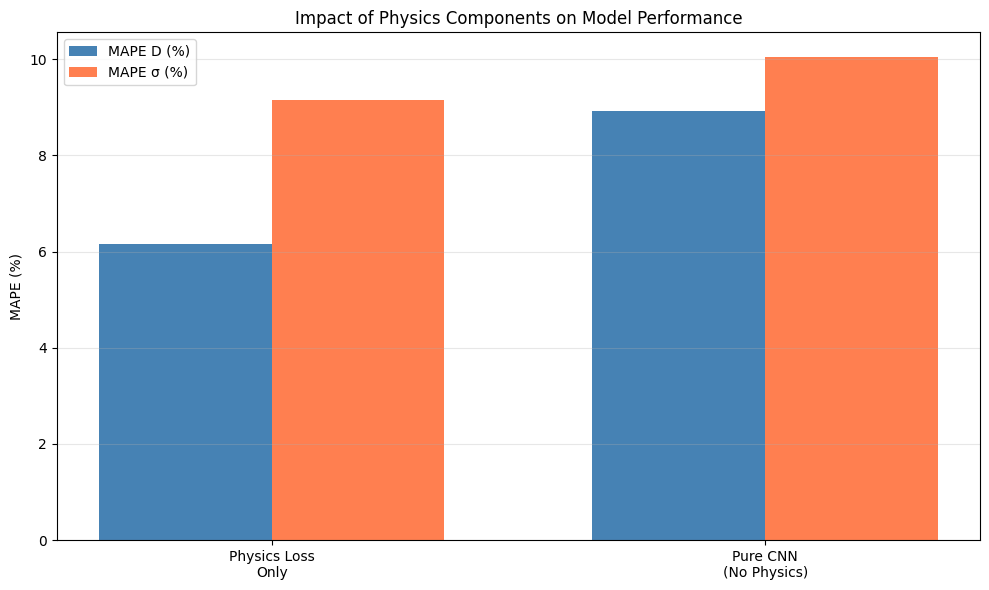

✓ Plot saved to: ablation_results/physics_contribution.png


In [8]:
# ==============================================================================
# CELL: VISUALIZACIÓN DE RESULTADOS
# ==============================================================================

def plot_ablation_results(summary_df, all_results, save_dir='ablation_results'):
    """Create visualization of ablation study results."""
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # ==========================
    # 1. Bar plot: MAPE comparison
    # ==========================
    ax1 = axes[0, 0]
    x = np.arange(len(summary_df))
    width = 0.35
    
    bars1 = ax1.bar(x - width/2, summary_df['mape_D'], width, label='MAPE D', color='steelblue')
    bars2 = ax1.bar(x + width/2, summary_df['mape_sigma'], width, label='MAPE σ', color='coral')
    
    ax1.set_xlabel('Experiment')
    ax1.set_ylabel('MAPE (%)')
    ax1.set_title('MAPE Comparison Across Experiments')
    ax1.set_xticks(x)
    ax1.set_xticklabels(summary_df['experiment'], rotation=45, ha='right')
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for bar in bars1:
        ax1.annotate(f'{bar.get_height():.1f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        ax1.annotate(f'{bar.get_height():.1f}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                    xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)
    
    # ==========================
    # 2. Bar plot: Validation Loss
    # ==========================
    ax2 = axes[0, 1]
    colors = ['green' if exp == summary_df['best_val_loss'].min() else 'steelblue' 
              for exp in summary_df['best_val_loss']]
    bars = ax2.bar(summary_df['experiment'], summary_df['best_val_loss'], color=colors)
    ax2.set_xlabel('Experiment')
    ax2.set_ylabel('Best Validation Loss')
    ax2.set_title('Validation Loss Comparison')
    ax2.set_xticklabels(summary_df['experiment'], rotation=45, ha='right')
    ax2.grid(axis='y', alpha=0.3)
    
    # ==========================
    # 3. Training curves comparison
    # ==========================
    ax3 = axes[1, 0]
    for result in all_results:
        ax3.plot(result['history']['val_loss_total'], label=result['name'], alpha=0.8)
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Validation Loss')
    ax3.set_title('Training Curves - Validation Loss')
    ax3.legend(loc='upper right', fontsize=8)
    ax3.grid(alpha=0.3)
    ax3.set_yscale('log')
    
    # ==========================
    # 4. MAPE curves comparison
    # ==========================
    ax4 = axes[1, 1]
    for result in all_results:
        ax4.plot(result['history']['val_mape_D'], label=f"{result['name']} (D)", alpha=0.8, linestyle='-')
        ax4.plot(result['history']['val_mape_sigma'], label=f"{result['name']} (σ)", alpha=0.8, linestyle='--')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('MAPE (%)')
    ax4.set_title('MAPE Evolution During Training')
    ax4.legend(loc='upper right', fontsize=6, ncol=2)
    ax4.grid(alpha=0.3)
    
    plt.tight_layout()
    
    # Save
    plot_path = os.path.join(save_dir, 'ablation_comparison.png')
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Plot saved to: {plot_path}")


def plot_physics_contribution(summary_df, save_dir='ablation_results'):
    """
    Specific plot showing the contribution of physics components.
    """
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Categorize experiments
    categories = {
        'full_physics': 'Full Physics\n(Input + Loss)',
        'pure_cnn': 'Pure CNN\n(No Physics)',
        'no_physics_loss': 'Physics Input\nOnly',
        'physics_loss_only': 'Physics Loss\nOnly',
    }
    
    # Filter to key experiments
    key_exps = summary_df[summary_df['experiment'].isin(categories.keys())].copy()
    key_exps['category'] = key_exps['experiment'].map(categories)
    
    # Sort by MAPE
    key_exps = key_exps.sort_values('mape_D')
    
    # Plot
    x = np.arange(len(key_exps))
    width = 0.35
    
    ax.bar(x - width/2, key_exps['mape_D'], width, label='MAPE D (%)', color='steelblue')
    ax.bar(x + width/2, key_exps['mape_sigma'], width, label='MAPE σ (%)', color='coral')
    
    ax.set_ylabel('MAPE (%)')
    ax.set_title('Impact of Physics Components on Model Performance')
    ax.set_xticks(x)
    ax.set_xticklabels(key_exps['category'])
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    # Add improvement annotation
    if 'pure_cnn' in key_exps['experiment'].values and 'full_physics' in key_exps['experiment'].values:
        pure_mape = key_exps[key_exps['experiment'] == 'pure_cnn']['mape_D'].values[0]
        full_mape = key_exps[key_exps['experiment'] == 'full_physics']['mape_D'].values[0]
        improvement = (pure_mape - full_mape) / pure_cnn * 100
        ax.annotate(f'Physics improves D prediction by {improvement:.1f}%',
                   xy=(0.5, 0.95), xycoords='axes fraction', ha='center',
                   fontsize=10, fontweight='bold',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    plt.tight_layout()
    
    plot_path = os.path.join(save_dir, 'physics_contribution.png')
    plt.savefig(plot_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"✓ Plot saved to: {plot_path}")


# Llamar después de correr los experimentos:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
summary_df = pd.read_csv('ablation_results/ablation_summary.csv')
#plot_ablation_results(summary_df, all_results)
plot_physics_contribution(summary_df)

In [ ]:
# ==============================================================================
# EXTRAER MÉTRICAS DEL MEJOR MODELO DESDE EL HISTORIAL
# ==============================================================================

import pandas as pd
import torch
from pathlib import Path

# =============================================================================
# CONFIGURACIÓN
# =============================================================================
MODEL_PATH = Path("outputs_ablation_final/physics_guided_mzvar0.4_annealing_nonfiltered/checkpoints/best_physics_guided_mzvar0.4_annealing_nonfiltered.pt")
HISTORY_CSV = Path("outputs_ablation_final/physics_guided_mzvar0.4_annealing_nonfiltered/checkpoints/best_physics_guided_mzvar0.4_annealing_nonfiltered_history.csv")

# =============================================================================
# CARGAR CHECKPOINT (solo para obtener la época del mejor modelo)
# =============================================================================
checkpoint = torch.load(MODEL_PATH, map_location='gpu', weights_only=False)
best_epoch = checkpoint['epoch']
best_val_loss = checkpoint['val_loss']

print(f"✓ Checkpoint: {MODEL_PATH.name}")
print(f"  Mejor época: {best_epoch}")
print(f"  Val loss: {best_val_loss:.6f}")
print(f"  Loss weights: {checkpoint['loss_weights']}")

# =============================================================================
# CARGAR HISTORIAL Y EXTRAER MÉTRICAS DE LA MEJOR ÉPOCA
# =============================================================================
history_df = pd.read_csv(HISTORY_CSV)

# Filtrar la fila de la mejor época
best_row = history_df[history_df['epoch'] == best_epoch].iloc[0]

# Extraer métricas
mape_D = best_row['val_mape_D']
mape_sigma = best_row['val_mape_sigma']
val_loss = best_row['val_loss_total']
train_loss = best_row['train_loss_total']

print(f"\n" + "="*60)
print(f"MÉTRICAS DEL MEJOR MODELO (Época {best_epoch})")
print("="*60)
print(f"  D     → MAPE = {mape_D:.1f}%")
print(f"  σ     → MAPE = {mape_sigma:.1f}%")
print(f"  Val loss: {val_loss:.6f}")
print(f"  Train loss: {train_loss:.6f}")
print("="*60)

# =============================================================================
# TABLA LATEX
# =============================================================================
print(f"""
\\begin{{table}}[htbp]
\\centering
\\caption{{Métricas del modelo Physics-Guided CNN (mejor época: {best_epoch}).}}
\\label{{tab:best_model_metrics}}
\\begin{{tabular}}{{lcc}}
\\toprule
Métrica & $D$ (DMI) & $\\sigma$ (Dispersión) \\\\
\\midrule
MAPE (\\%) & {mape_D:.1f} & {mape_sigma:.1f} \\\\
\\bottomrule
\\end{{tabular}}
\\end{{table}}
""")

✓ Checkpoint: best_physics_guided_mzvar0.4_annealing_nonfiltered.pt
  Mejor época: 93
  Val loss: 0.011791
  Loss weights: {'regression': 1.0, 'spectral_sigma': 0.0, 'mz_var_sigma': 0.4}

MÉTRICAS DEL MEJOR MODELO (Época 93)
  D     → MAPE = 4.5%
  σ     → MAPE = 7.1%
  Val loss: 0.011791
  Train loss: 0.009741

\begin{table}[htbp]
\centering
\caption{Métricas del modelo Physics-Guided CNN (mejor época: 93).}
\label{tab:best_model_metrics}
\begin{tabular}{lcc}
\toprule
Métrica & $D$ (DMI) & $\sigma$ (Dispersión) \\
\midrule
MAPE (\%) & 4.5 & 7.1 \\
\bottomrule
\end{tabular}
\end{table}



In [340]:
# ==============================================================================
# CELL 12: FINAL EVALUATION (UPDATED)
# ==============================================================================

model.eval()

# Collect predictions SEPARATELY for train and val
train_preds, train_targets = [], []
val_preds, val_targets = [], []

with torch.no_grad():
    # Training data (UPDATED: 5 items)
    for imgs, m_fields, Ku_blocks, targets, run_ids in train_loader:
        imgs = imgs.to(device)
        with torch.amp.autocast('cuda', enabled=use_amp):
            outputs = model(imgs)
        preds_unnorm = outputs * t_std_t + t_mean_t
        targets_unnorm = targets.to(device) * t_std_t + t_mean_t
        train_preds.append(preds_unnorm.cpu())
        train_targets.append(targets_unnorm.cpu())
    
    # Validation data (UPDATED: 5 items)
    for imgs, m_fields, Ku_blocks, targets, run_ids in val_loader:
        imgs = imgs.to(device)
        with torch.amp.autocast('cuda', enabled=use_amp):
            outputs = model(imgs)
        preds_unnorm = outputs * t_std_t + t_mean_t
        targets_unnorm = targets.to(device) * t_std_t + t_mean_t
        val_preds.append(preds_unnorm.cpu())
        val_targets.append(targets_unnorm.cpu())

# Concatenate
train_preds = torch.cat(train_preds)
train_targets = torch.cat(train_targets)
val_preds = torch.cat(val_preds)
val_targets = torch.cat(val_targets)

# For plotting: combine all
all_preds = torch.cat([train_preds, val_preds])
all_targets = torch.cat([train_targets, val_targets])

D_pred, D_true = all_preds[:, 0], all_targets[:, 0]
s_pred, s_true = all_preds[:, 1], all_targets[:, 1]

# Separate for metrics
D_pred_train, D_true_train = train_preds[:, 0], train_targets[:, 0]
s_pred_train, s_true_train = train_preds[:, 1], train_targets[:, 1]

D_pred_val, D_true_val = val_preds[:, 0], val_targets[:, 0]
s_pred_val, s_true_val = val_preds[:, 1], val_targets[:, 1]

# -------------------------------------------------
# Compute metrics function
# -------------------------------------------------
def compute_metrics(pred, true, min_denom=None):
    """Compute R², MAE, RMSE, MAPE for a set of predictions."""
    # R²
    ss_res = torch.sum((true - pred)**2)
    ss_tot = torch.sum((true - torch.mean(true))**2)
    r2 = (1 - ss_res / ss_tot).item() if ss_tot > 0 else 0.0
    
    # MAE, RMSE
    mae = torch.mean(torch.abs(pred - true)).item()
    rmse = torch.sqrt(torch.mean((pred - true)**2)).item()
    
    # MAPE
    if min_denom is not None:
        mask = true > min_denom
        if mask.sum() > 0:
            mape = torch.mean(torch.abs((pred[mask] - true[mask]) / true[mask])).item() * 100
        else:
            mape = float('nan')
    else:
        mape = torch.mean(torch.abs((pred - true) / (true.abs() + 1e-8))).item() * 100
    
    return {'r2': r2, 'mae': mae, 'rmse': rmse, 'mape': mape}

# Compute metrics
train_D_metrics = compute_metrics(D_pred_train, D_true_train, min_denom=1e-4)
train_s_metrics = compute_metrics(s_pred_train, s_true_train, min_denom=0.01)
val_D_metrics = compute_metrics(D_pred_val, D_true_val, min_denom=1e-4)
val_s_metrics = compute_metrics(s_pred_val, s_true_val, min_denom=0.01)

# -------------------------------------------------
# Print results
# -------------------------------------------------
print("\n" + "="*80)
print(f"FINAL METRICS ({RUN_TAG})")
print("="*80)

print(f"\nTRAINING SET (n={len(train_preds)}) - Model has seen this data")
print(f"   D → R²={train_D_metrics['r2']:.3f}, MAPE={train_D_metrics['mape']:.1f}%")
print(f"   σ → R²={train_s_metrics['r2']:.3f}, MAPE={train_s_metrics['mape']:.1f}%")

print(f"\nVALIDATION SET (n={len(val_preds)}) - TRUE GENERALIZATION")
print(f"   D → R²={val_D_metrics['r2']:.3f}, MAPE={val_D_metrics['mape']:.1f}%")
print(f"   σ → R²={val_s_metrics['r2']:.3f}, MAPE={val_s_metrics['mape']:.1f}%")

print("="*80)


checkpoint = torch.load(BEST_PATH, weights_only=False)
print(f"Best model es de época: {checkpoint['epoch']}")
# Use validation metrics for plot titles
r2_D = val_D_metrics['r2']
r2_s = val_s_metrics['r2']
mape_D = val_D_metrics['mape']
mape_s = val_s_metrics['mape']


FINAL METRICS (physics_guided_spectral0.8_nonfiltered)

TRAINING SET (n=2610) - Model has seen this data
   D → R²=0.998, MAPE=2.1%
   σ → R²=0.996, MAPE=2.7%

VALIDATION SET (n=461) - TRUE GENERALIZATION
   D → R²=0.994, MAPE=3.8%
   σ → R²=0.980, MAPE=6.6%
Best model es de época: 69


✓ Training history saved to outputs_ablation_final/physics_guided_spectral0.8_nonfiltered/figures/training_history_physics_guided_spectral0.8_nonfiltered.csv

Final metrics from training history:
  MAPE D: 4.8%
  MAPE σ: 7.8%
  Val Loss: 1.6338e-02


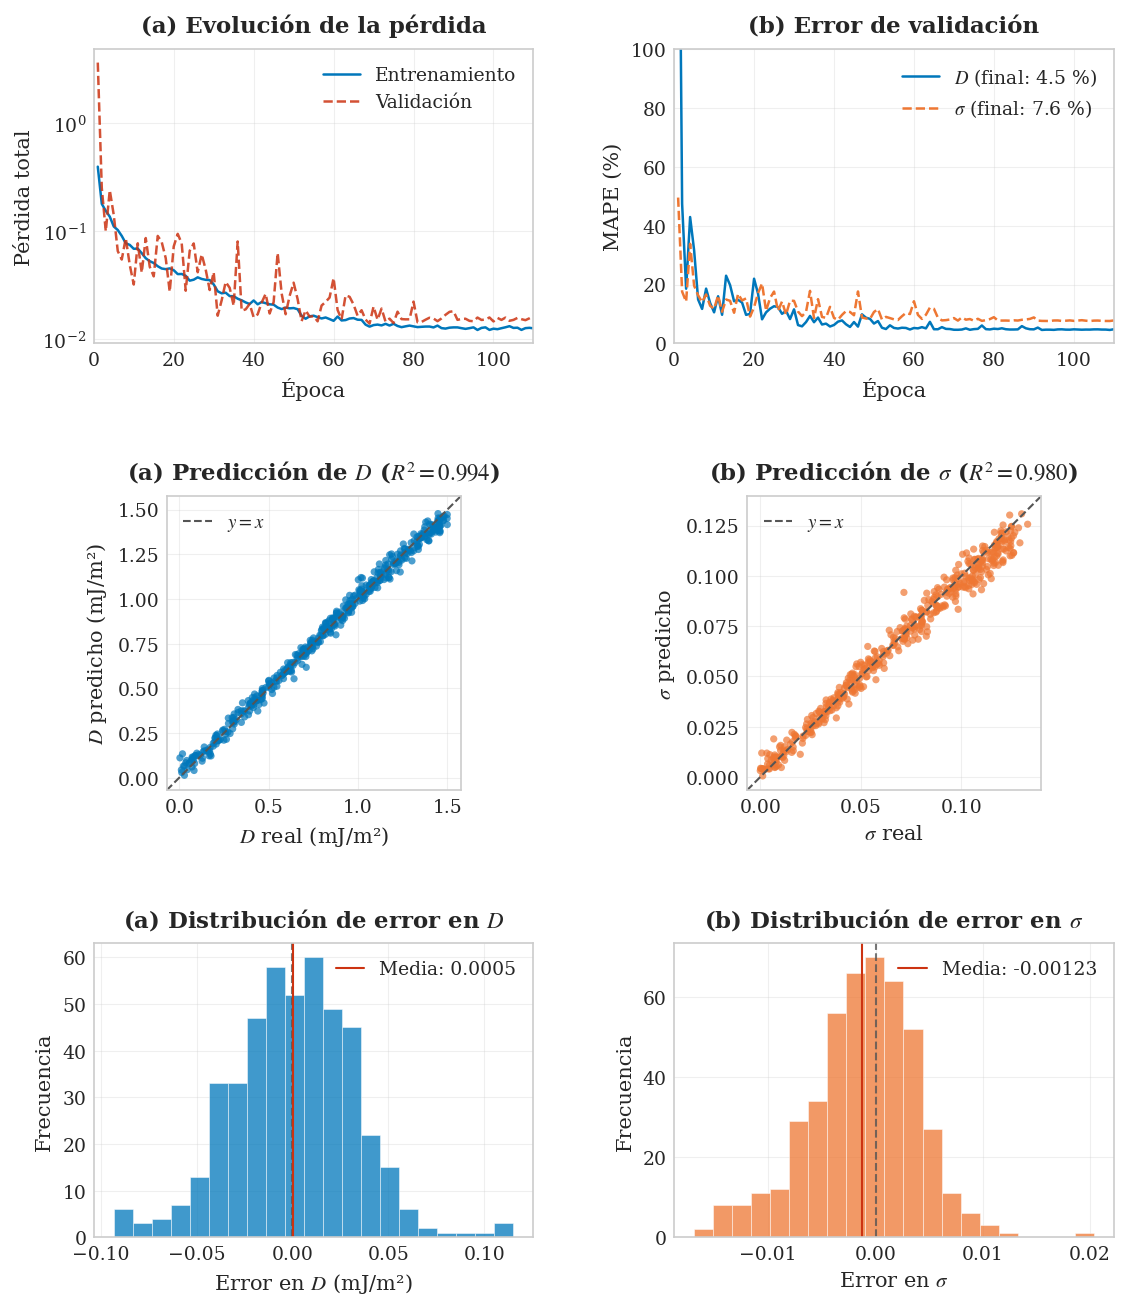


✓ Figures saved:
   PNG: outputs_ablation_final/physics_guided_spectral0.8_nonfiltered/figures/results_physics_guided_spectral0.8_nonfiltered.png
   PDF: outputs_ablation_final/physics_guided_spectral0.8_nonfiltered/figures/results_physics_guided_spectral0.8_nonfiltered.pdf

TABLA LATEX PARA EL DOCUMENTO

\begin{table}[htbp]
\centering
\caption{Métricas de desempeño del modelo Physics-Guided CNN en el conjunto de validación 
          ($n = 461$ muestras).}
\label{tab:metrics}
\begin{tabular}{lcc}
\toprule
Métrica & $D$ (DMI) & $\sigma$ (Dispersión de anisotropía) \\
\midrule
$R^2$ & 0.994 & 0.980 \\
MAPE (\%) & 4.8 & 7.8 \\
MAE & 0.0252 mJ/m² & 0.00398 \\
Sesgo (media del error) & 0.0005 mJ/m² & -0.00123 \\
\bottomrule
\end{tabular}
\end{table}



In [341]:
# ==============================================================================
# CELL 13: VISUALIZATION (UPDATED)
# ==============================================================================

import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
from pathlib import Path

# =============================================================================
# 1. SAVE TRAINING HISTORY TO CSV (UPDATED)
# =============================================================================
history_df = pd.DataFrame({
    'epoch': np.arange(1, len(history['train_loss_total']) + 1),
    'train_loss_total': history['train_loss_total'],
    'train_loss_reg': history['train_loss_reg'],
    'train_loss_spectral_sigma': history['train_loss_spectral_sigma'],    # UPDATED
    'train_loss_mz_var_sigma': history['train_loss_mz_var_sigma'],        # NEW
    'val_loss_total': history['val_loss_total'],
    'val_loss_reg': history['val_loss_reg'],
    'val_loss_spectral_sigma': history['val_loss_spectral_sigma'],        # UPDATED
    'val_loss_mz_var_sigma': history['val_loss_mz_var_sigma'],            # NEW
    'val_mape_D': history['val_mape_D'],
    'val_mape_sigma': history['val_mape_sigma'],
    'lr': history['lr'],
    'weight_spectral_sigma': history['weight_spectral_sigma'],            # UPDATED
    'weight_mz_var_sigma': history['weight_mz_var_sigma'],                # NEW
})

csv_path = FIG_DIR / f"training_history_{RUN_TAG}.csv"
history_df.to_csv(csv_path, index=False)
print(f"✓ Training history saved to {csv_path}")

# =============================================================================
# 2. THESIS-READY STYLE CONFIGURATION
# =============================================================================

# Paleta de colores profesional
COLORS = {
    'train': '#0077BB',
    'val': '#CC3311',
    'D': '#0077BB',
    'sigma': '#EE7733',
    'regression': '#0077BB',
    'spectral_sigma': '#009988',    # UPDATED
    'mz_var_sigma': '#EE3377',      # NEW
    'reference': '#555555',
    'highlight': '#CC3311',
    'neutral': '#BBBBBB',
}

# Aplicar estilo (si tienes esta función definida)
# setup_thesis_style()

# =============================================================================
# 3. GET FINAL VALUES FROM HISTORY
# =============================================================================
final_mape_D = history['val_mape_D'][-1]
final_mape_sigma = history['val_mape_sigma'][-1]
final_val_loss = history['val_loss_total'][-1]

print(f"\nFinal metrics from training history:")
print(f"  MAPE D: {final_mape_D:.1f}%")
print(f"  MAPE σ: {final_mape_sigma:.1f}%")
print(f"  Val Loss: {final_val_loss:.4e}")

# =============================================================================
# 4. CREATE MAIN FIGURE
# =============================================================================

fig = plt.figure(figsize=(8.0, 8.9))
gs = fig.add_gridspec(3, 2, hspace=0.52, wspace=0.32,
                      left=0.10, right=0.95, top=0.95, bottom=0.06)

epochs = np.arange(1, len(history['train_loss_total']) + 1)

# -------------------------------------------------------------------------
# (a) Loss Evolution
# -------------------------------------------------------------------------
ax1 = fig.add_subplot(gs[0, 0])

ax1.semilogy(epochs, history['train_loss_total'], 
             color=COLORS['train'], linewidth=1.2, label='Entrenamiento')
ax1.semilogy(epochs, history['val_loss_total'], 
             color=COLORS['val'], linewidth=1.2, linestyle='--', 
             alpha=0.85, label='Validación')

ax1.set_xlabel('Época')
ax1.set_ylabel('Pérdida total')
ax1.set_title('(a) Evolución de la pérdida', fontweight='semibold', pad=8)
ax1.legend(loc='upper right')
ax1.set_xlim([0, len(epochs)])

# -------------------------------------------------------------------------
# (b) Validation MAPE
# -------------------------------------------------------------------------
ax2 = fig.add_subplot(gs[0, 1])

val_D = mape_D
val_s = mape_sigma

ax2.plot(epochs, history['val_mape_D'], 
         color=COLORS['D'], linewidth=1.2,
         label=f'$D$ (final: 4.5 %)')
ax2.plot(epochs, history['val_mape_sigma'], 
         color=COLORS['sigma'], linewidth=1.2, linestyle='--',
         label=f'$\\sigma$ (final: 7.6 %)')

ax2.set_xlabel('Época')
ax2.set_ylabel('MAPE (%)')
ax2.set_title('(b) Error de validación', fontweight='semibold', pad=8)
ax2.legend(loc='upper right')
ax2.set_ylim(bottom=0, top=min(100, max(max(history['val_mape_D'][:30]), 
                                         max(history['val_mape_sigma'][:30])) * 1.1))
ax2.set_xlim([0, len(epochs)])

# -------------------------------------------------------------------------
# (c) D Prediction Scatter
# -------------------------------------------------------------------------
ax3 = fig.add_subplot(gs[1, 0])

D_plot = D_pred_val.numpy() * 1e3
D_true_plot = D_true_val.numpy() * 1e3

n_points = len(D_plot)
alpha = max(0.3, min(0.7, 500/n_points))

ax3.scatter(D_true_plot, D_plot, s=12, alpha=alpha, 
            c=COLORS['D'], edgecolors='none', rasterized=True)

d_min = min(D_true_plot.min(), D_plot.min())
d_max = max(D_true_plot.max(), D_plot.max())
d_margin = (d_max - d_min) * 0.05
d_lim = [d_min - d_margin, d_max + d_margin]

ax3.plot(d_lim, d_lim, '--', color=COLORS['reference'], 
         linewidth=1.0, label='$y = x$', zorder=1)

ax3.set_xlabel('$D$ real (mJ/m²)')
ax3.set_ylabel('$D$ predicho (mJ/m²)')
ax3.set_title(f'(a) Predicción de $D$ ($R^2 = {r2_D:.3f}$)', 
              fontweight='semibold', pad=8)
ax3.set_xlim(d_lim)
ax3.set_ylim(d_lim)
ax3.set_aspect('equal', adjustable='box')
ax3.legend(loc='upper left', handlelength=1.5)

# -------------------------------------------------------------------------
# (d) σ Prediction Scatter
# -------------------------------------------------------------------------
ax4 = fig.add_subplot(gs[1, 1])

s_plot = s_pred_val.numpy()
s_true_plot = s_true_val.numpy()

ax4.scatter(s_true_plot, s_plot, s=12, alpha=alpha,
            c=COLORS['sigma'], edgecolors='none', rasterized=True)

s_min = min(s_true_plot.min(), s_plot.min())
s_max = max(s_true_plot.max(), s_plot.max())
s_margin = (s_max - s_min) * 0.05
s_lim = [s_min - s_margin, s_max + s_margin]

ax4.plot(s_lim, s_lim, '--', color=COLORS['reference'], 
         linewidth=1.0, label='$y = x$', zorder=1)

ax4.set_xlabel('$\\sigma$ real')
ax4.set_ylabel('$\\sigma$ predicho')
ax4.set_title(f'(b) Predicción de $\\sigma$ ($R^2 = {r2_s:.3f}$)', 
              fontweight='semibold', pad=8)
ax4.set_xlim(s_lim)
ax4.set_ylim(s_lim)
ax4.set_aspect('equal', adjustable='box')
ax4.legend(loc='upper left', handlelength=1.5)

# -------------------------------------------------------------------------
# (e) D Error Distribution
# -------------------------------------------------------------------------


ax5 = fig.add_subplot(gs[2, 0])

D_error = (D_pred_val - D_true_val).numpy() * 1e3
mae_D = np.mean(np.abs(D_error))
mae_rel_D = mae_D / D_true.mean() * 100  # En porcentaje
mean_D_error = np.mean(D_error)

n_bins = min(30, max(15, int(np.sqrt(len(D_error)))))
ax5.hist(D_error, bins=n_bins, alpha=0.75, color=COLORS['D'], 
         edgecolor='white', linewidth=0.3)

ax5.axvline(0, color=COLORS['reference'], linestyle='--', 
            linewidth=1.0, alpha=0.8)
ax5.axvline(mean_D_error, color=COLORS['highlight'], linestyle='-', 
            linewidth=1.0, label=f'Media: {mean_D_error:.4f}')

ax5.set_xlabel('Error en $D$ (mJ/m²)')
ax5.set_ylabel('Frecuencia')
ax5.set_title(f'(a) Distribución de error en $D$', 
              fontweight='semibold', pad=8)
ax5.legend(loc='upper right', handlelength=1.5)

# -------------------------------------------------------------------------
# (f) σ Error Distribution
# -------------------------------------------------------------------------
ax6 = fig.add_subplot(gs[2, 1])

s_error = (s_pred_val - s_true_val).numpy()
mae_s = np.mean(np.abs(s_error))
mae_rel_s = mae_s / s_true.mean() * 100
mean_s_error = np.mean(s_error)

ax6.hist(s_error, bins=n_bins, alpha=0.75, color=COLORS['sigma'],
         edgecolor='white', linewidth=0.3)

ax6.axvline(0, color=COLORS['reference'], linestyle='--', 
            linewidth=1.0, alpha=0.8)
ax6.axvline(mean_s_error, color=COLORS['highlight'], linestyle='-', 
            linewidth=1.0, label=f'Media: {mean_s_error:.5f}')

ax6.set_xlabel('Error en $\\sigma$')
ax6.set_ylabel('Frecuencia')
ax6.set_title(f'(b) Distribución de error en $\\sigma$', 
              fontweight='semibold', pad=8)
ax6.legend(loc='upper right', handlelength=1.5)

# =============================================================================
# 5. SAVE FIGURE
# =============================================================================
fig_path = FIG_DIR / f"results_{RUN_TAG}.png"
plt.savefig(fig_path, dpi=300, bbox_inches='tight', facecolor='white')

pdf_path = FIG_DIR / f"results_{RUN_TAG}.pdf"
plt.savefig(pdf_path, format='pdf', bbox_inches='tight', facecolor='white')

plt.show()

print(f"\n✓ Figures saved:")
print(f"   PNG: {fig_path}")
print(f"   PDF: {pdf_path}")

# =============================================================================
# 6. LATEX TABLE (UPDATED - Physics-Guided CNN, not PINN)
# =============================================================================
print("\n" + "="*60)
print("TABLA LATEX PARA EL DOCUMENTO")
print("="*60)
print(f"""
\\begin{{table}}[htbp]
\\centering
\\caption{{Métricas de desempeño del modelo Physics-Guided CNN en el conjunto de validación 
          ($n = {len(D_plot)}$ muestras).}}
\\label{{tab:metrics}}
\\begin{{tabular}}{{lcc}}
\\toprule
Métrica & $D$ (DMI) & $\\sigma$ (Dispersión de anisotropía) \\\\
\\midrule
$R^2$ & {r2_D:.3f} & {r2_s:.3f} \\\\
MAPE (\\%) & {final_mape_D:.1f} & {final_mape_sigma:.1f} \\\\
MAE & {mae_D:.4f} mJ/m² & {mae_s:.5f} \\\\
Sesgo (media del error) & {mean_D_error:.4f} mJ/m² & {mean_s_error:.5f} \\\\
\\bottomrule
\\end{{tabular}}
\\end{{table}}
""")

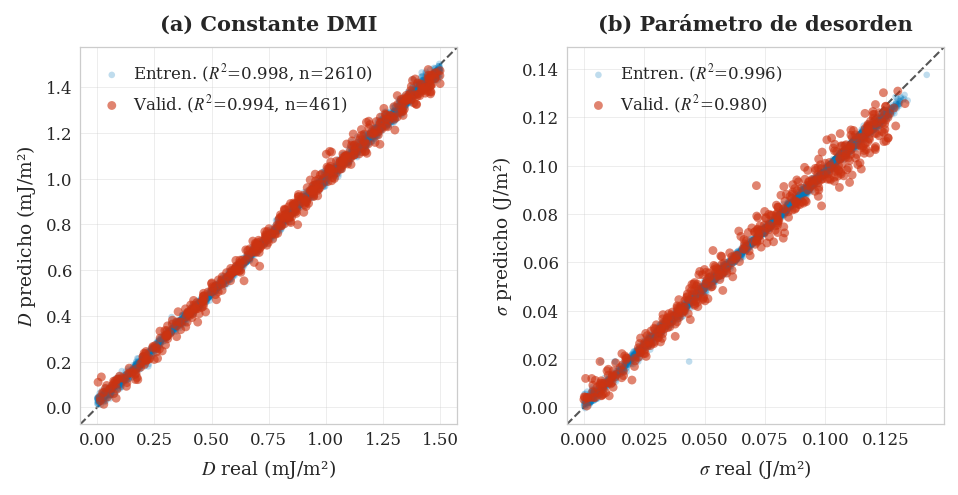


✓ Figura guardada:
   PNG: outputs_ablation_final/physics_guided_spectral0.8_nonfiltered/figures/train_vs_val_physics_guided_spectral0.8_nonfiltered.png
   PDF: outputs_ablation_final/physics_guided_spectral0.8_nonfiltered/figures/train_vs_val_physics_guided_spectral0.8_nonfiltered.pdf

COMPARACIÓN ENTRENAMIENTO VS VALIDACIÓN
Métrica              Entrenamiento     Validación       
-------------------------------------------------------
R² (D)               0.9984            0.9940           
R² (σ)               0.9958            0.9804           
n muestras           2610              461              

\begin{table}[htbp]
\centering
\caption{Comparación del desempeño en conjuntos de entrenamiento y validación.}
\label{tab:train_val_comparison}
\begin{tabular}{lccc}
\toprule
Parámetro & Conjunto & $R^2$ & $n$ \\
\midrule
\multirow{2}{*}{$D$ (DMI)} 
    & Entrenamiento & 0.998 & 2610 \\
    & Validación & 0.994 & 461 \\
\midrule
\multirow{2}{*}{$\sigma$ (Desorden)} 
    & Entrenamien

In [342]:
# ==============================================================================
# TRAIN VS VAL SCATTER PLOTS (Thesis-ready style)
# ==============================================================================

model.eval()
train_preds, train_targets = [], []
val_preds, val_targets = [], []
#device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#
#BEST_PATH = CHECKPOINT_DIR / f"best_model_{RUN_TAG}.pt"
#checkpoint = torch.load(BEST_PATH, map_location=device, weights_only=False)
# 
# 
#
## Cargar modelo
#model = PhysicsGuidedCNN()  # Asegúrate de tener la clase definida
#model.load_state_dict(checkpoint['model_state_dict'])
#model.to(device)
#model.eval()
#
## Cargar estadísticas de normalización
#t_mean_t = torch.tensor(checkpoint['target_mean'])
#t_std_t = torch.tensor(checkpoint['target_std'])
#
#print(f"✓ Modelo cargado desde: {BEST_PATH}")
#print(f"  Época: {checkpoint['epoch']}")
#print(f"  Val loss: {checkpoint['val_loss']:.6f}")
#print(f"  Loss weights: {checkpoint['loss_weights']}")


with torch.no_grad():
    # CORREGIDO: 5 elementos
    for imgs, m_fields, Ku_blocks, targets, run_ids in train_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds_unnorm = outputs.cpu() * t_std_t.cpu() + t_mean_t.cpu()
        targets_unnorm = targets * t_std_t.cpu() + t_mean_t.cpu()
        train_preds.append(preds_unnorm)
        train_targets.append(targets_unnorm)
    
    # CORREGIDO: 5 elementos
    for imgs, m_fields, Ku_blocks, targets, run_ids in val_loader:
        imgs = imgs.to(device)
        outputs = model(imgs)
        preds_unnorm = outputs.cpu() * t_std_t.cpu() + t_mean_t.cpu()
        targets_unnorm = targets * t_std_t.cpu() + t_mean_t.cpu()
        val_preds.append(preds_unnorm)
        val_targets.append(targets_unnorm)

train_preds = torch.cat(train_preds).numpy()
train_targets = torch.cat(train_targets).numpy()
val_preds = torch.cat(val_preds).numpy()
val_targets = torch.cat(val_targets).numpy()

# =============================================================================
# Compute R² for each split
# =============================================================================
def compute_r2(pred, true):
    ss_res = np.sum((true - pred)**2)
    ss_tot = np.sum((true - np.mean(true))**2)
    return 1 - ss_res / ss_tot if ss_tot > 0 else 0

r2_D_train = compute_r2(train_preds[:, 0], train_targets[:, 0])
r2_D_val = compute_r2(val_preds[:, 0], val_targets[:, 0])
r2_s_train = compute_r2(train_preds[:, 1], train_targets[:, 1])
r2_s_val = compute_r2(val_preds[:, 1], val_targets[:, 1])

# =============================================================================
# Thesis-ready style (consistent with main results figure)
# =============================================================================
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'DejaVu Serif', 'Liberation Serif'],
    'mathtext.fontset': 'stix',
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'axes.linewidth': 0.6,
    'grid.linewidth': 0.4,
    'grid.alpha': 0.4,
    'lines.linewidth': 1.2,
})

# Colores consistentes con figura principal
COLORS = {
    'train': '#0077BB',      # Azul - entrenamiento
    'val': '#CC3311',        # Rojo - validación
    'reference': '#555555',  # Gris - línea y=x
}

# =============================================================================
# Create figure
# =============================================================================
fig, axes = plt.subplots(1, 2, figsize=(6.5, 3.2))

# Preparar datos
D_train_true = train_targets[:, 0] * 1e3  # a mJ/m²
D_train_pred = train_preds[:, 0] * 1e3
D_val_true = val_targets[:, 0] * 1e3
D_val_pred = val_preds[:, 0] * 1e3

s_train_true = train_targets[:, 1]
s_train_pred = train_preds[:, 1]
s_val_true = val_targets[:, 1]
s_val_pred = val_preds[:, 1]

n_train = len(train_preds)
n_val = len(val_preds)

# -------------------------------------------------------------------------
# (a) D prediction
# -------------------------------------------------------------------------
ax = axes[0]

# Training data (fondo, más transparente)
ax.scatter(D_train_true, D_train_pred, 
           s=10, alpha=0.25, c=COLORS['train'], edgecolors='none',
           label=f'Entren. ($R^2$={r2_D_train:.3f}, n={n_train})',
           rasterized=True)

# Validation data (frente, más visible)
ax.scatter(D_val_true, D_val_pred, 
           s=18, alpha=0.6, c=COLORS['val'], edgecolors='none',
           label=f'Valid. ($R^2$={r2_D_val:.3f}, n={n_val})',
           rasterized=True)

# Línea de predicción perfecta
d_min = min(D_train_true.min(), D_val_true.min())
d_max = max(D_train_true.max(), D_val_true.max())
d_margin = (d_max - d_min) * 0.05
d_lim = [d_min - d_margin, d_max + d_margin]

ax.plot(d_lim, d_lim, '--', color=COLORS['reference'], 
        linewidth=1.0, zorder=0)

ax.set_xlabel('$D$ real (mJ/m²)')
ax.set_ylabel('$D$ predicho (mJ/m²)')
ax.set_title('(a) Constante DMI', fontweight='semibold', pad=8)
ax.legend(loc='upper left', framealpha=0.95, edgecolor='0.8',
          handletextpad=0.3, borderpad=0.4)
ax.set_xlim(d_lim)
ax.set_ylim(d_lim)
ax.set_aspect('equal', adjustable='box')

# -------------------------------------------------------------------------
# (b) σ prediction
# -------------------------------------------------------------------------
ax = axes[1]

# Training data
ax.scatter(s_train_true, s_train_pred,
           s=10, alpha=0.25, c=COLORS['train'], edgecolors='none',
           label=f'Entren. ($R^2$={r2_s_train:.3f})',
           rasterized=True)

# Validation data
ax.scatter(s_val_true, s_val_pred,
           s=18, alpha=0.6, c=COLORS['val'], edgecolors='none',
           label=f'Valid. ($R^2$={r2_s_val:.3f})',
           rasterized=True)

# Línea de predicción perfecta
s_min = min(s_train_true.min(), s_val_true.min())
s_max = max(s_train_true.max(), s_val_true.max())
s_margin = (s_max - s_min) * 0.05
s_lim = [s_min - s_margin, s_max + s_margin]

ax.plot(s_lim, s_lim, '--', color=COLORS['reference'], 
        linewidth=1.0, zorder=0)

ax.set_xlabel('$\\sigma$ real (J/m²)')
ax.set_ylabel('$\\sigma$ predicho (J/m²)')
ax.set_title('(b) Parámetro de desorden', fontweight='semibold', pad=8)
ax.legend(loc='upper left', framealpha=0.95, edgecolor='0.8',
          handletextpad=0.3, borderpad=0.4)
ax.set_xlim(s_lim)
ax.set_ylim(s_lim)
ax.set_aspect('equal', adjustable='box')

# =============================================================================
# Save
# =============================================================================
plt.tight_layout(w_pad=1.5)

fig_path = FIG_DIR / f"train_vs_val_{RUN_TAG}.png"
pdf_path = FIG_DIR / f"train_vs_val_{RUN_TAG}.pdf"

plt.savefig(fig_path, dpi=300, bbox_inches='tight', facecolor='white', edgecolor='none')
plt.savefig(pdf_path, format='pdf', bbox_inches='tight', facecolor='white')
plt.show()

print(f"\n✓ Figura guardada:")
print(f"   PNG: {fig_path}")
print(f"   PDF: {pdf_path}")

# =============================================================================
# Summary table
# =============================================================================
print(f"\n{'='*55}")
print(f"COMPARACIÓN ENTRENAMIENTO VS VALIDACIÓN")
print(f"{'='*55}")
print(f"{'Métrica':<20} {'Entrenamiento':<17} {'Validación':<17}")
print(f"{'-'*55}")
print(f"{'R² (D)':<20} {r2_D_train:<17.4f} {r2_D_val:<17.4f}")
print(f"{'R² (σ)':<20} {r2_s_train:<17.4f} {r2_s_val:<17.4f}")
print(f"{'n muestras':<20} {n_train:<17} {n_val:<17}")
print(f"{'='*55}")

# LaTeX table
print(f"""
\\begin{{table}}[htbp]
\\centering
\\caption{{Comparación del desempeño en conjuntos de entrenamiento y validación.}}
\\label{{tab:train_val_comparison}}
\\begin{{tabular}}{{lccc}}
\\toprule
Parámetro & Conjunto & $R^2$ & $n$ \\\\
\\midrule
\\multirow{{2}}{{*}}{{$D$ (DMI)}} 
    & Entrenamiento & {r2_D_train:.3f} & {n_train} \\\\
    & Validación & {r2_D_val:.3f} & {n_val} \\\\
\\midrule
\\multirow{{2}}{{*}}{{$\\sigma$ (Desorden)}} 
    & Entrenamiento & {r2_s_train:.3f} & {n_train} \\\\
    & Validación & {r2_s_val:.3f} & {n_val} \\\\
\\bottomrule
\\end{{tabular}}
\\end{{table}}
""")